# Canonical NBA Play-by-Play Dataset

**Goal:** Build a unified play-by-play dataset for backtesting sports betting algorithms.

## Data source

All NBA data comes from `cdn.nba.com` REST endpoints (no auth required):

| Dataset | S3 key pattern | Description |
|---------|---------------|-------------|
| Schedule | `nba_cdn/schedule/season_{year}.json` | Full season schedule with game IDs, dates, teams |
| Play-by-play | `nba_cdn/play_by_play/{game_id}.json` | Per-action PBP with `timeActual` (wall-clock timestamps) |
| Box scores | `nba_cdn/boxscore/{game_id}.json` | Per-player and team stats |
| Live PBP | `bronze/nba_cdn/live_pbp/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | Real-time PBP captured by live ingester |

The CDN PBP endpoint provides 56 fields per action including `timeActual` (ISO 8601 wall-clock timestamp), which is essential for joining game state to Kalshi market timestamps.

## Approach

1. Explore game-level data (season schedule, completed games)
2. Explore PBP schema and receipt latency (NBA CDN)
3. Explore Kalshi market data and receipt latency (Kalshi WS)
4. Join NBA game state to Kalshi market prices

In [177]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

S3_BUCKET = "prediction-markets-data"
s3 = boto3.client("s3")

## 1. Game-level exploration

Load the season schedule from S3 to understand coverage and pick sample games for PBP exploration.

In [178]:
# List what's in the nba_cdn/ prefix
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="nba_cdn/", Delimiter="/")
for prefix in resp.get("CommonPrefixes", []):
    print(prefix["Prefix"])

nba_cdn/boxscore/
nba_cdn/play_by_play/
nba_cdn/schedule/


In [179]:
# Load season schedule from S3
SEASON = "2025-26"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/schedule/season_{SEASON}.json")
schedule_raw = json.loads(obj["Body"].read())

# Flatten schedule into a games dataframe
games = []
for game_date in schedule_raw["leagueSchedule"]["gameDates"]:
    for g in game_date["games"]:
        games.append({
            "game_id": g["gameId"],
            "game_date": g["gameDateEst"],
            "game_status": g["gameStatus"],  # 1=scheduled, 2=in-progress, 3=final
            "home_team": g["homeTeam"]["teamTricode"],
            "away_team": g["awayTeam"]["teamTricode"],
            "game_label": g.get("gameLabel", ""),
        })

df = pd.DataFrame(games)

# Derive game type from game_id prefix (3rd digit)
game_type_map = {"1": "Preseason", "2": "Regular Season", "3": "All-Star", "4": "Playoffs"}
df["game_type"] = df["game_id"].astype(str).str[2].map(game_type_map)

completed = df[df["game_status"] == 3]
print(f"{len(df)} total games, {len(completed)} completed")
print(f"\nBy type:")
print(df["game_type"].value_counts())
df.head()

1378 total games, 1321 completed

By type:
game_type
Regular Season    1230
Preseason           71
Playoffs            63
All-Star             7
Name: count, dtype: int64


,game_id,game_date,game_status,home_team,away_team,game_label,game_type
0,0012500008,2025-10-02T00:00:00Z,3,NYK,PHI,Preseason,Preseason
1,0012500001,2025-10-03T00:00:00Z,3,LAL,PHX,Preseason,Preseason
2,0012500009,2025-10-03T00:00:00Z,3,NOP,MEL,Preseason,Preseason
3,0012500010,2025-10-04T00:00:00Z,3,PHI,NYK,Preseason,Preseason
4,0012500011,2025-10-04T00:00:00Z,3,NOP,SEM,Preseason,Preseason


In [180]:
df["game_type"].value_counts()

game_type
Regular Season    1230
Preseason           71
Playoffs            63
All-Star             7
Name: count, dtype: int64

In [181]:
df.shape

(1378, 7)

In [182]:
df.describe()

,game_status
count,1378.000000
mean,2.917997
std,0.395815
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,3.000000


## 2. Play-by-play exploration

### CDN PBP

Source: `cdn.nba.com/static/json/liveData/playbyplay/playbyplay_{game_id}.json`
- S3 path: `s3://prediction-markets-data/nba_cdn/play_by_play/{game_id}.json`
- Coverage: all completed games backfilled via `fetch_play_by_play --season`
- 56 fields per action including `timeActual` (wall-clock ISO timestamp)

In [183]:
# Pick a completed regular season game
sample_game = completed[completed["game_type"] == "Regular Season"].iloc[0]
sample_game_id = sample_game["game_id"]
print(f"Game: {sample_game_id} ({sample_game['away_team']} @ {sample_game['home_team']}, {sample_game['game_date']})")

# Load PBP from S3
obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{sample_game_id}.json")
pbp_raw = json.loads(obj["Body"].read())
actions = pbp_raw.get("game", {}).get("actions", [])
pbp_df = pd.DataFrame(actions)
print(f"{len(pbp_df)} actions, {pbp_df.shape[1]} columns")
print(f"\nColumns: {pbp_df.columns.tolist()}")
pbp_df.head(10)

Game: 0022500001 (HOU @ OKC, 2025-10-21T00:00:00Z)
707 actions, 56 columns

Columns: ['actionNumber', 'clock', 'timeActual', 'period', 'periodType', 'actionType', 'subType', 'qualifiers', 'personId', 'x', 'y', 'possession', 'scoreHome', 'scoreAway', 'edited', 'orderNumber', 'isTargetScoreLastPeriod', 'xLegacy', 'yLegacy', 'isFieldGoal', 'side', 'description', 'personIdsFilter', 'teamId', 'teamTricode', 'descriptor', 'jumpBallRecoveredName', 'jumpBallRecoverdPersonId', 'playerName', 'playerNameI', 'jumpBallWonPlayerName', 'jumpBallWonPersonId', 'jumpBallLostPlayerName', 'jumpBallLostPersonId', 'area', 'areaDetail', 'shotDistance', 'shotResult', 'shotActionNumber', 'reboundTotal', 'reboundDefensiveTotal', 'reboundOffensiveTotal', 'pointsTotal', 'assistPlayerNameInitial', 'assistPersonId', 'assistTotal', 'officialId', 'foulPersonalTotal', 'foulTechnicalTotal', 'foulDrawnPlayerName', 'foulDrawnPersonId', 'turnoverTotal', 'stealPlayerName', 'stealPersonId', 'blockPlayerName', 'blockPersonId

,actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,xLegacy,yLegacy,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,officialId,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,turnoverTotal,stealPlayerName,stealPersonId,blockPlayerName,blockPersonId
0,2,PT12M00.00S,2025-10-21T23:43:24.7Z,1,REGULAR,period,start,[],0,NaN,NaN,0,0,0,2025-10-21T23:43:24Z,20000,False,NaN,NaN,0,NaN,Period Start,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,PT11M56.00S,2025-10-21T23:43:27.2Z,1,REGULAR,jumpball,recovered,[],1641708,NaN,NaN,1610612745,0,0,2025-10-21T23:43:27Z,40000,False,NaN,NaN,0,NaN,Jump Ball S. Adams vs. C. Holmgren: Tip to A. Thompson,"[1641708, 203500, 1631096]",1.610613e+09,HOU,startperiod,A. Thompson,1641708.0,Thompson,A. Thompson,Adams,203500.0,Holmgren,1631096.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,PT11M36.00S,2025-10-21T23:43:59.9Z,1,REGULAR,3pt,Jump Shot,[],1630578,24.655059,85.784314,1610612745,0,0,2025-10-21T23:44:05Z,80000,False,-179.0,179.0,1,left,MISS A. Sengun 25' 3PT,[1630578],1.610613e+09,HOU,NaN,NaN,NaN,Sengun,A. Sengun,NaN,NaN,NaN,NaN,Above the Break 3,24+ Left Center,25.33,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,PT11M31.00S,2025-10-21T23:44:04.9Z,1,REGULAR,rebound,defensive,[],1641717,NaN,NaN,1610612760,0,0,2025-10-21T23:44:05Z,90000,False,NaN,NaN,0,NaN,C. Wallace REBOUND (Off:0 Def:1),[1641717],1.610613e+09,OKC,NaN,NaN,NaN,Wallace,C. Wallace,NaN,NaN,NaN,NaN,Above the Break 3,24+ Left Center,NaN,NaN,8.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10,PT11M26.00S,2025-10-21T23:44:12.5Z,1,REGULAR,2pt,Layup,[pointsinthepaint],1631096,92.986202,50.000000,1610612760,2,0,2025-10-21T23:44:19Z,100000,False,0.0,13.0,1,right,C. Holmgren cutting Layup (2 PTS) (L. Dort 1 AST),"[1631096, 1629652]",1.610613e+09,OKC,cutting,NaN,NaN,Holmgren,C. Holmgren,NaN,NaN,NaN,NaN,Restricted Area,0-8 Center,1.34,Made,NaN,NaN,NaN,NaN,2.0,L. Dort,1629652.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,12,PT11M26.00S,2025-10-21T23:44:14.3Z,1,REGULAR,foul,personal,[1freethrow],1631095,NaN,NaN,1610612760,2,0,2025-10-21T23:44:24Z,120000,False,NaN,NaN,0,NaN,J. Smith Jr. shooting personal FOUL (1 PF) (Holmgren 1 FT),"[1631095, 1631096]",1.610613e+09,HOU,shooting,NaN,NaN,Smith Jr.,J. Smith Jr.,NaN,NaN,NaN,NaN,Restricted Area,0-8 Center,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200833.0,1.0,0.0,Holmgren,1631096.0,NaN,NaN,NaN,NaN,NaN
6,14,PT11M26.00S,2025-10-21T23:44:48.5Z,1,REGULAR,freethrow,1 of 1,[],1631096,NaN,NaN,1610612760,3,0,2025-10-21T23:44:48Z,140000,False,NaN,NaN,0,NaN,C. Holmgren Free Throw 1 of 1 (3 PTS),[1631096],1.610613e+09,OKC,NaN,NaN,NaN,Holmgren,C. Holmgren,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Made,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,15,PT11M08.00S,2025-10-21T23:45:08.6Z,1,REGULAR,3pt,Jump Shot,[],1641708,5.601183,3.431373,1610612745,3,0,2025-10-21T23:45:14Z,150000,False,233.0,0.0,1,left,MISS A. Thompson 3PT,[1641708],1.610613e+09,HOU,NaN,NaN,NaN,Thompson,A. Thompson,NaN,NaN,NaN,NaN,Right Corner 3,24+ Right,23.28,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,16,PT11M04.00S,2025-10-21T23:45:12.6Z,1,REGULAR,rebound,offensive,[],1631095,NaN,NaN,1610612745,3,0,2025-10-21T23:45:14Z,160000,False,NaN,NaN,0,NaN,J. Smith Jr. REBOUND (Off:1 Def:0),[1631095],1.610613e+09,HOU,NaN,NaN

### Receipt latency — NBA CDN

`timeActual` is when the play happened on court. `t_receipt` is when our poller received it.
The difference tells us how stale PBP data is in production — important for backtesting
so we don't act on game state we wouldn't have seen yet.

Actions with lag >60s are excluded (first-poll catch-up on already-happened actions).

In [184]:
# Load bronze live PBP to measure t_receipt - timeActual
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="bronze/nba_cdn/live_pbp/")
nba_bronze_keys = [o["Key"] for o in resp.get("Contents", [])]

nba_records = []
for key in nba_bronze_keys[:200]:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    raw = gzip.decompress(obj["Body"].read())
    for line in raw.decode().strip().split("\n"):
        r = json.loads(line)
        nba_records.append({
            "timeActual": r["frame"].get("timeActual"),
            "t_receipt": r.get("t_receipt"),
        })

nba_lag_df = pd.DataFrame(nba_records)
nba_lag_df["ta"] = pd.to_datetime(nba_lag_df["timeActual"], utc=True)
nba_lag_df["tr"] = pd.to_datetime(nba_lag_df["t_receipt"], unit="s", utc=True)
nba_lag_df["lag"] = (nba_lag_df["tr"] - nba_lag_df["ta"]).dt.total_seconds()

# Exclude first-poll catch-up actions
nba_lag_steady = nba_lag_df[nba_lag_df["lag"] <= 60]["lag"]
print(f"{len(nba_lag_df)} total actions, {len(nba_lag_steady)} steady-state (lag <= 60s)")
print(f"Median: {nba_lag_steady.median():.1f}s, p95: {nba_lag_steady.quantile(0.95):.1f}s")
nba_lag_df.head()

1432 total actions, 1031 steady-state (lag <= 60s)
Median: 12.0s, p95: 38.5s


,timeActual,t_receipt,ta,tr,lag
0,2026-04-18T22:54:14.2Z,1.776553e+09,2026-04-18 22:54:14.200000+00:00,2026-04-18 22:54:20.960214853+00:00,6.760215
1,2026-04-18T22:54:35.5Z,1.776553e+09,2026-04-18 22:54:35.500000+00:00,2026-04-18 22:54:48.722672701+00:00,13.222673
2,2026-04-18T22:54:36.5Z,1.776553e+09,2026-04-18 22:54:36.500000+00:00,2026-04-18 22:54:48.722672701+00:00,12.222673
3,2026-04-18T22:37:56.8Z,1.776552e+09,2026-04-18 22:37:56.800000+00:00,2026-04-18 22:38:10.655314445+00:00,13.855314
4,2026-04-18T22:37:59.8Z,1.776552e+09,2026-04-18 22:37:59.800000+00:00,2026-04-18 22:38:10.655314445+00:00,10.855314


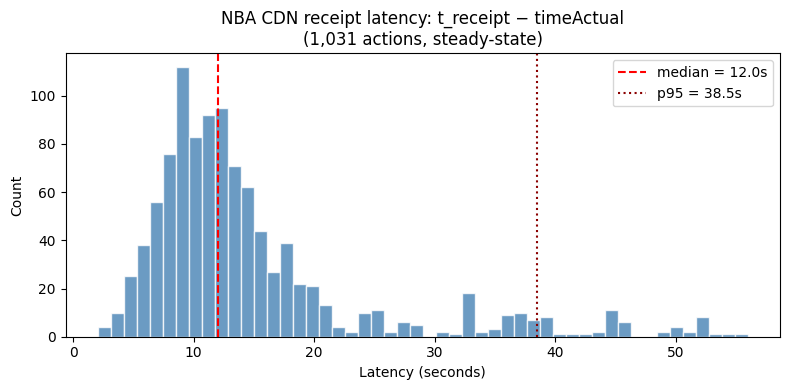

In [185]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nba_lag_steady, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(nba_lag_steady.median(), color="red", linestyle="--",
           label=f"median = {nba_lag_steady.median():.1f}s")
ax.axvline(nba_lag_steady.quantile(0.95), color="darkred", linestyle=":",
           label=f"p95 = {nba_lag_steady.quantile(0.95):.1f}s")
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Count")
ax.set_title(f"NBA CDN receipt latency: t_receipt − timeActual\n({len(nba_lag_steady):,} actions, steady-state)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Kalshi market data

Kalshi data has **no game state fields** (`period`, `clock`, `score`). It is purely market data. The only way to correlate market prices with game state is via wall-clock time.

**Kalshi data in S3:**

| Dataset | S3 key pattern | Key fields |
|---------|---------------|------------|
| Historical markets | `kalshi/historical_markets/{series}.json` | `ticker`, `event_ticker`, `title`, `open_time`, `close_time`, `result` |
| Historical trades | `kalshi/historical_trades/{ticker}.json` | `ticker`, `price`, `count`, `taker_side`, `created_time` |
| Historical candlesticks | `kalshi/historical_candlesticks/{interval}m/{ticker}.json` | OHLC + `volume` + `timestamp` |
| Live orderbook snapshots | `bronze/kalshi_ws/orderbook_snapshot/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, `bids`, `asks` |
| Live orderbook deltas | `bronze/kalshi_ws/orderbook_delta/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, price/size deltas |
| Live trades | `bronze/kalshi_ws/trade/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, `price`, `count`, `taker_side`, `created_time` |

In [186]:
# Load a sample historical markets file (e.g. KXNBAGAME — win/loss)
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAGAME.json")
markets_raw = json.loads(obj["Body"].read())
markets_df = pd.DataFrame(markets_raw)
print(f"{len(markets_df)} markets")
print(f"\nColumns: {markets_df.columns.tolist()}")
markets_df.head(2)

1902 markets

Columns: ['can_close_early', 'close_time', 'created_time', 'custom_strike', 'early_close_condition', 'event_ticker', 'expected_expiration_time', 'expiration_time', 'expiration_value', 'fractional_trading_enabled', 'last_price_dollars', 'latest_expiration_time', 'liquidity_dollars', 'market_type', 'no_ask_dollars', 'no_bid_dollars', 'no_sub_title', 'notional_value_dollars', 'open_interest_fp', 'open_time', 'previous_price_dollars', 'previous_yes_ask_dollars', 'previous_yes_bid_dollars', 'price_level_structure', 'price_ranges', 'response_price_units', 'result', 'rules_primary', 'rules_secondary', 'settlement_timer_seconds', 'settlement_ts', 'settlement_value_dollars', 'status', 'strike_type', 'tick_size', 'ticker', 'title', 'updated_time', 'volume_24h_fp', 'volume_fp', 'yes_ask_dollars', 'yes_ask_size_fp', 'yes_bid_dollars', 'yes_bid_size_fp', 'yes_sub_title']


,can_close_early,close_time,created_time,custom_strike,early_close_condition,event_ticker,expected_expiration_time,expiration_time,expiration_value,fractional_trading_enabled,last_price_dollars,latest_expiration_time,liquidity_dollars,market_type,no_ask_dollars,no_bid_dollars,no_sub_title,notional_value_dollars,open_interest_fp,open_time,previous_price_dollars,previous_yes_ask_dollars,previous_yes_bid_dollars,price_level_structure,price_ranges,response_price_units,result,rules_primary,rules_secondary,settlement_timer_seconds,settlement_ts,settlement_value_dollars,status,strike_type,tick_size,ticker,title,updated_time,volume_24h_fp,volume_fp,yes_ask_dollars,yes_ask_size_fp,yes_bid_dollars,yes_bid_size_fp,yes_sub_title
0,True,2026-02-13T05:37:28Z,2026-02-10T17:02:09.225173Z,{'basketball_team': '2ef4d31c-0b46-4f43-a403-f44d62489034'},This market will close and expire after a winner is declared.,KXNBAGAME-26FEB12DALLAL,2026-02-13T06:00:00Z,2026-02-27T03:00:00Z,Los Angeles L,False,0.9900,2026-02-27T03:00:00Z,0.0000,binary,1.0000,0.0000,Los Angeles L,1.0000,0.00,2026-02-10T22:06:00Z,0.9900,1.0000,0.0000,linear_cent,"[{'end': '1.0000', 'start': '0.0000', 'step': '0.0100'}]",usd_cent,yes,"If Los Angeles L wins the Dallas at Los Angeles L professional basketball game originally scheduled for Feb 12, 2026, then the market resolves to Yes.",,30,2026-02-13T05:39:01.690752Z,1.0000,finalized,structured,1,KXNBAGAME-26FEB12DALLAL-LAL,Dallas at Los Angeles L Winner?,2026-02-19T08:48:16.628714Z,0.00,4954411.00,1.0000,0.00,0.0000,0.00,Los Angeles L
1,True,2026-02-13T05:37:28Z,2026-02-10T17:02:09.225173Z,{'basketball_team': '36547ae6-f0fa-4d06-a6e5-5bfa64a217ed'},This market will close and expire after a winner is declared.,KXNBAGAME-26FEB12DALLAL,2026-02-13T06:00:00Z,2026-02-27T03:00:00Z,Los Angeles L,False,0.0100,2026-02-27T03:00:00Z,0.0000,binary,1.0000,0.0000,Dallas,1.0000,0.00,2026-02-10T22:06:00Z,0.0100,1.0000,0.0000,linear_cent,"[{'end': '1.0000', 'start': '0.0000', 'step': '0.0100'}]",usd_cent,no,"If Dallas wins the Dallas at Los Angeles L professional basketball game originally scheduled for Feb 12, 2026, then the market resolves to Yes.",,30,2026-02-13T05:39:01.690752Z,0.0000,finalized,structured,1,KXNBAGAME-26FEB12DALLAL-DAL,Dallas at Los Angeles L Winner?,2026-02-19T08:48:16.628714Z,0.00,3744380.00,1.0000,0.00,0.0000,0.00,Dallas


In [187]:
# Load trades for one ticker to see the schema
sample_ticker = markets_df["ticker"].iloc[0]
print(f"Sample ticker: {sample_ticker}")

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{sample_ticker}.json")
trades_raw = json.loads(obj["Body"].read())
trades_df = pd.DataFrame(trades_raw)
print(f"{len(trades_df)} trades")
print(f"Columns: {trades_df.columns.tolist()}")
trades_df.head()

Sample ticker: KXNBAGAME-26FEB12DALLAL-LAL
22533 trades
Columns: ['count_fp', 'created_time', 'no_price_dollars', 'taker_side', 'ticker', 'trade_id', 'yes_price_dollars']


,count_fp,created_time,no_price_dollars,taker_side,ticker,trade_id,yes_price_dollars
0,15.00,2026-02-13T05:30:39.335643Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,3f8fa67d-6fbf-40e0-5f40-6fe027f593a3,0.9900
1,52.00,2026-02-13T05:30:37.195315Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,973b978b-87bf-4a28-fd3c-1acc939fdd77,0.9900
2,20.00,2026-02-13T05:30:34.13469Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,39ffa7cd-b71f-5b80-1dfa-529b3df1485b,0.9900
3,6.00,2026-02-13T05:30:33.604435Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,c6333019-83a7-561c-eba4-748526b6b773,0.9900
4,19.00,2026-02-13T05:30:32.710968Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,7074d157-0383-4bc8-2f9c-38e05e56698f,0.9900


In [188]:
# Load live Kalshi WS trades from bronze
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/trade/")
kalshi_bronze_keys = [obj["Key"] for obj in resp.get("Contents", [])]
print(f"{len(kalshi_bronze_keys)} bronze kalshi_ws/trade files in S3")

if kalshi_bronze_keys:
    all_ws_trades = []
    for key in kalshi_bronze_keys[:20]:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
        raw_bytes = gzip.decompress(obj["Body"].read())
        for line in raw_bytes.decode().strip().split("\n"):
            record = json.loads(line)
            frame = record["frame"]
            # WS trade frames have msg nested inside
            msg = frame.get("msg", {})
            msg["t_receipt"] = record.get("t_receipt")
            all_ws_trades.append(msg)
    ws_trades_df = pd.DataFrame(all_ws_trades)
    print(f"Read {len(kalshi_bronze_keys[:20])} files, {len(ws_trades_df)} trades")
    print(f"\nColumns: {ws_trades_df.columns.tolist()}")
    ws_trades_df.head(10)
else:
    print("No bronze kalshi_ws/trade data yet — run: python -m scripts.live.kalshi_ws")

ws_trades_df['latency'] = ws_trades_df['t_receipt'] - ws_trades_df['ts']
ws_trades_df.head()

1000 bronze kalshi_ws/trade files in S3
Read 20 files, 20723 trades

Columns: ['trade_id', 'market_ticker', 'yes_price_dollars', 'no_price_dollars', 'count_fp', 'taker_side', 'ts', 't_receipt']


,trade_id,market_ticker,yes_price_dollars,no_price_dollars,count_fp,taker_side,ts,t_receipt,latency
0,7a22e120-d6f4-4e74-455f-66ce14a4a774,KXNBASPREAD-26APR18HOULAL-LAL7,0.3300,0.6700,35.00,yes,1776560193,1.776560e+09,0.978654
1,ce1bd8a6-6665-4f2a-4067-c9d85c241740,KXNBASPREAD-26APR18HOULAL-LAL7,0.3300,0.6700,22.00,yes,1776560193,1.776560e+09,0.978673
2,03fbfd64-cc40-4a05-b818-a0f4887f3e0e,KXNBATOTAL-26APR18HOULAL-198,0.8600,0.1400,12.00,yes,1776560193,1.776560e+09,0.985253
3,4a0a2ea7-5cda-477f-8aec-ba83af8d608a,KXNBATOTAL-26APR18HOULAL-198,0.8600,0.1400,54.37,yes,1776560193,1.776560e+09,0.985382
4,07f1f331-d4d8-741c-30a1-0d1d0aeb847a,KXNBAGAME-26APR18HOULAL-HOU,0.4800,0.5200,100.00,yes,1776560194,1.776560e+09,0.148268


### Receipt latency — Kalshi WS

`ts` is the exchange timestamp (when the trade executed on Kalshi). `t_receipt` is when our
WebSocket client received the message. Sub-second latency is expected for a direct WS connection.

This latency matters for backtesting: when we join Kalshi prices to NBA game state,
we need to account for the fact that in a live system we'd see trade data ~0.5s after execution.

In [189]:
kalshi_lag = ws_trades_df["t_receipt"] - ws_trades_df["ts"]
print(f"{len(kalshi_lag):,} trades, median lag {kalshi_lag.median():.3f}s, p95 {kalshi_lag.quantile(0.95):.3f}s")

20,723 trades, median lag 0.526s, p95 0.985s


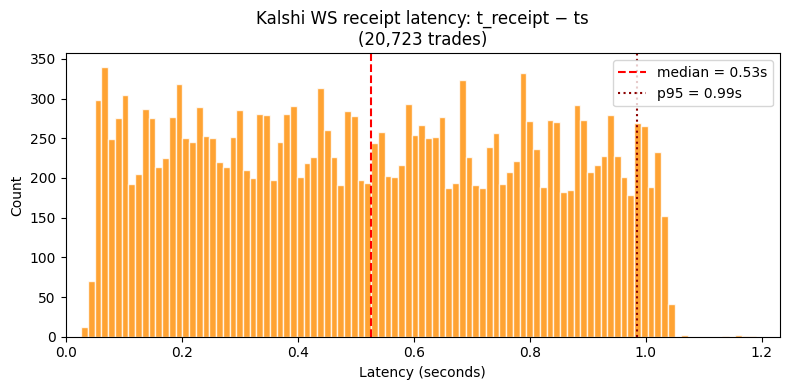

In [190]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(kalshi_lag, bins=100, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(kalshi_lag.median(), color="red", linestyle="--",
           label=f"median = {kalshi_lag.median():.2f}s")
ax.axvline(kalshi_lag.quantile(0.95), color="darkred", linestyle=":",
           label=f"p95 = {kalshi_lag.quantile(0.95):.2f}s")
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Count")
ax.set_title(f"Kalshi WS receipt latency: t_receipt − ts\n({len(kalshi_lag):,} trades)")
ax.legend()
ax.set_xlim(0, kalshi_lag.quantile(0.99) * 1.2)
plt.tight_layout()
plt.show()

## 4. Joining Kalshi to NBA game state

To backtest betting strategies we need to answer: **what was the market price when each play happened?**

Since Kalshi has no game state fields, we join on wall-clock time:
1. **Map ticker to game**: parse `event_ticker` to extract date + teams, match to NBA `game_id`
2. **Join on wall-clock time**: `merge_asof` aligns Kalshi `created_time` to NBA `timeActual`

**Lag caveat**: In a live system, NBA CDN data arrives ~12s after the play (median) and Kalshi
WS data arrives ~0.5s after trade execution. The join below uses raw timestamps — a realistic
backtest should shift `timeActual` forward by the observed NBA CDN lag to avoid look-ahead bias.

### 4a. Mapping Kalshi event_ticker → NBA game_id

The `event_ticker` encodes the game: `KXNBAGAME-{YY}{MON}{DD}{AWAY}{HOME}`

For example: `KXNBAGAME-25DEC25MINDEN` → Dec 25, 2025, MIN @ DEN

We can parse this and match against the CDN schedule to get the `game_id`.

In [191]:
MONTH_MAP = {
    "JAN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAY": "05", "JUN": "06", "JUL": "07", "AUG": "08",
    "SEP": "09", "OCT": "10", "NOV": "11", "DEC": "12",
}

# Build schedule lookup: (date, away, home) -> game_id
schedule_lookup = {}
for game_date in schedule_raw["leagueSchedule"]["gameDates"]:
    for g in game_date["games"]:
        date_str = g["gameDateEst"][:10]
        away = g["awayTeam"].get("teamTricode", "")
        home = g["homeTeam"].get("teamTricode", "")
        if away and home:
            schedule_lookup[(date_str, away, home)] = g["gameId"]

def parse_event_ticker(event_ticker: str):
    """Parse KXNBAGAME-{YY}{MON}{DD}{AWAY}{HOME} into (date, away, home, game_id)."""
    m = re.match(r"KXNBAGAME-(\d{2})([A-Z]{3})(\d{2})(.{3})(.{3})", event_ticker)
    if not m:
        return None
    yy, mon, dd, away, home = m.groups()
    date_str = f"20{yy}-{MONTH_MAP[mon]}-{dd}"
    game_id = schedule_lookup.get((date_str, away, home))
    return {"date": date_str, "away": away, "home": home, "game_id": game_id}

# Test match rate
matched = sum(1 for et in markets_df["event_ticker"].unique() if (p := parse_event_ticker(et)) and p["game_id"])
total = markets_df["event_ticker"].nunique()
print(f"Matched {matched}/{total} events to schedule ({total - matched} unmatched)")
print(f"  Unmatched are mostly 2024-25 season games (pre-Oct 2025) or postponed games")

Matched 861/951 events to schedule (90 unmatched)
  Unmatched are mostly 2024-25 season games (pre-Oct 2025) or postponed games


### 4b. Joined dataset — MIN @ DEN, Dec 25 2025

Christmas Day game: Timberwolves at Nuggets. Highest Kalshi volume game in the dataset (~31.5M contracts).

**Join strategy**: `pd.merge_asof` on wall-clock time — for each NBA action, find the most recent Kalshi trade. This gives us "what was the market price at the time of each play?"

In [192]:
# --- Load PBP for MIN @ DEN, Dec 25 2025 ---
GAME_ID = "0022500013"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{GAME_ID}.json")
pbp_raw = json.loads(obj["Body"].read())
pbp = pd.DataFrame(pbp_raw["game"]["actions"])
pbp["timeActual"] = pd.to_datetime(pbp["timeActual"], utc=True)
print(f"PBP: {len(pbp)} actions, {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")

# --- Load Kalshi trades for both sides of the win/loss market ---
# Use the home team ticker (DEN) — yes_price = P(DEN wins)
HOME_TICKER = "KXNBAGAME-25DEC25MINDEN-DEN"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{HOME_TICKER}.json")
trades = pd.DataFrame(json.loads(obj["Body"].read()))
trades["created_time"] = pd.to_datetime(trades["created_time"], utc=True)
trades["yes_price"] = trades["yes_price_dollars"].astype(float)
trades = trades.sort_values("created_time").reset_index(drop=True)
print(f"Trades: {len(trades)} for {HOME_TICKER}")

# Filter trades to game window (first PBP action to last)
game_start = pbp["timeActual"].min()
game_end = pbp["timeActual"].max()
in_game_trades = trades[(trades["created_time"] >= game_start) & (trades["created_time"] <= game_end)]
print(f"Trades during game: {len(in_game_trades)}")

PBP: 651 actions, 2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
Trades: 50049 for KXNBAGAME-25DEC25MINDEN-DEN
Trades during game: 43956


In [193]:
# --- merge_asof: for each PBP action, find the most recent trade price ---
pbp_sorted = pbp.sort_values("timeActual")
trades_sorted = in_game_trades[["created_time", "yes_price"]].sort_values("created_time")

joined = pd.merge_asof(
    pbp_sorted,
    trades_sorted,
    left_on="timeActual",
    right_on="created_time",
    direction="backward",
)

# yes_price = P(DEN wins) at the time of each play
joined = joined.rename(columns={"yes_price": "kalshi_home_win_prob"})

# Show key columns
display_cols = [
    "timeActual", "period", "clock", "actionType", "description",
    "scoreHome", "scoreAway", "kalshi_home_win_prob",
]
print(f"Joined: {len(joined)} rows, kalshi price filled for {joined['kalshi_home_win_prob'].notna().sum()}")
joined[display_cols].head(20)

Joined: 651 rows, kalshi price filled for 650


,timeActual,period,clock,actionType,description,scoreHome,scoreAway,kalshi_home_win_prob
0,2025-12-26 03:43:24.100000+00:00,1,PT12M00.00S,period,Period Start,0,0,NaN
1,2025-12-26 03:43:26.900000+00:00,1,PT11M56.00S,jumpball,Jump Ball R. Gobert vs. N. Jokić: Tip to D. DiVincenzo,0,0,0.49
2,2025-12-26 03:44:01.800000+00:00,1,PT11M35.00S,2pt,MISS J. Randle 16' fadeaway Shot,0,0,0.50
3,2025-12-26 03:44:03.800000+00:00,1,PT11M33.00S,rebound,TEAM defensive REBOUND,0,0,0.50
4,2025-12-26 03:44:32+00:00,1,PT11M10.00S,3pt,N. Jokić 24' 3PT (3 PTS) (S. Jones 1 AST),3,0,0.50
5,2025-12-26 03:44:48+00:00,1,PT10M55.00S,2pt,MISS R. Gobert 7' cutting Layup - blocked,3,0,0.50
6,2025-12-26 03:44:48+00:00,1,PT10M55.00S,block,N. Jokić BLOCK (1 BLK),3,0,0.50
7,2025-12-26 03:44:48+00:00,1,PT10M55.00S,rebound,TEAM offensive REBOUND,3,0,0.50
8,2025-12-26 03:45:05.200000+00:00,1,PT10M50.00S,turnover,A. Edwards lost ball out-of-bounds TURNOVER (1 TO),3,0,0.51
9,2025-12-26 03:45:16.600000+00:00,1,PT10M42.00S,steal,A. Edwards STEAL (1 STL),3,0,0.51


In [194]:
# Show scoring plays with market price movement
scoring = joined[joined["actionType"].isin(["2pt", "3pt"])].copy()
scoring["score_diff"] = scoring["scoreHome"].astype(int) - scoring["scoreAway"].astype(int)

print(f"MIN @ DEN, Dec 25 2025 — scoring plays with Kalshi P(DEN wins)")
print(f"{'':->90}")
scoring[["timeActual", "period", "clock", "description", "score_diff", "kalshi_home_win_prob"]].to_string()

MIN @ DEN, Dec 25 2025 — scoring plays with Kalshi P(DEN wins)
------------------------------------------------------------------------------------------


"                          timeActual  period        clock                                                                description  score_diff  kalshi_home_win_prob\n2   2025-12-26 03:44:01.800000+00:00       1  PT11M35.00S                                           MISS J. Randle 16' fadeaway Shot           0                  0.50\n4          2025-12-26 03:44:32+00:00       1  PT11M10.00S                                 N. Jokić 24' 3PT  (3 PTS) (S. Jones 1 AST)           3                  0.50\n5          2025-12-26 03:44:48+00:00       1  PT10M55.00S                                  MISS R. Gobert 7' cutting Layup - blocked           3                  0.50\n13         2025-12-26 03:45:27+00:00       1  PT10M31.00S                                             MISS J. Murray 24' running 3PT           3                  0.51\n15  2025-12-26 03:45:38.200000+00:00       1  PT10M20.00S                                          MISS A. Edwards 24' step back 3PT           3               

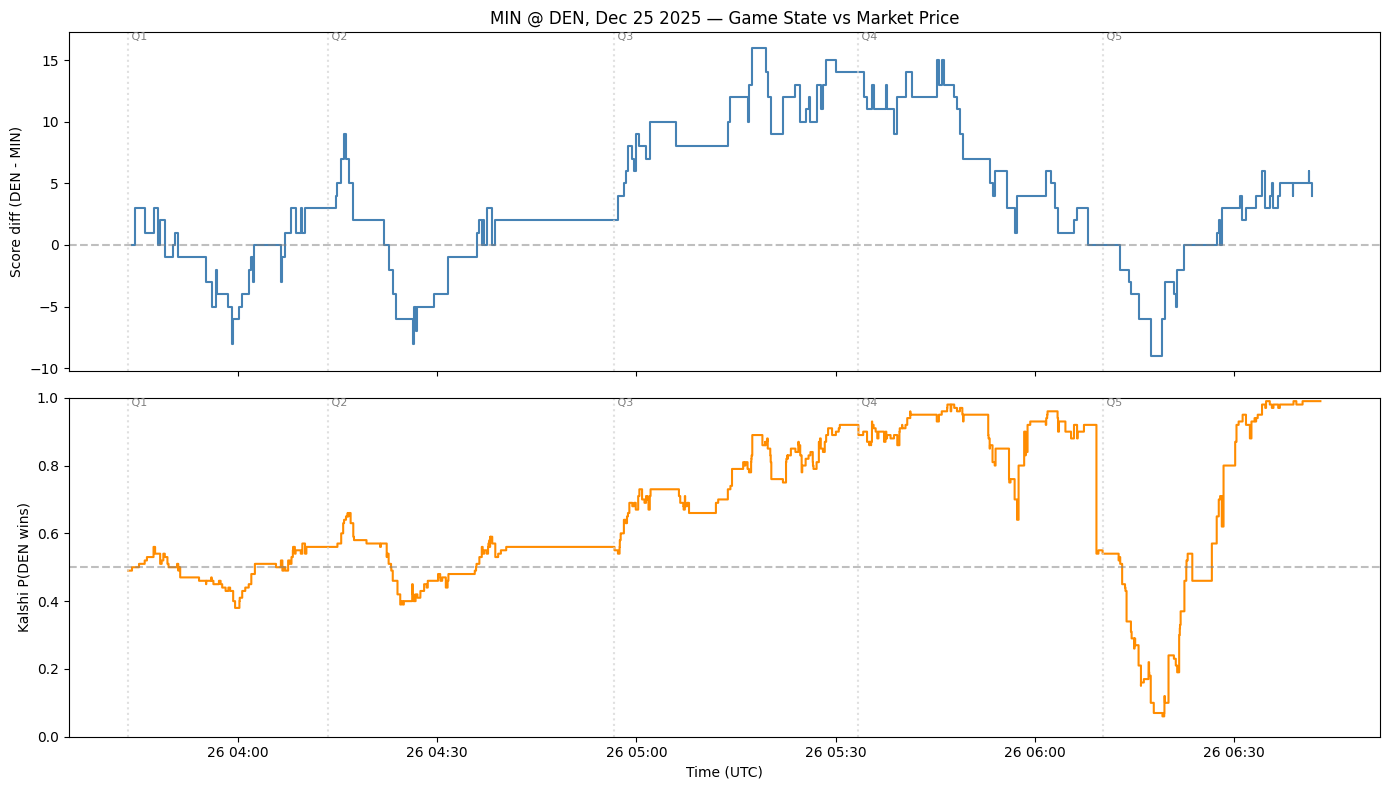

In [195]:
# Plot score differential vs Kalshi win probability over the game
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Score diff over time
scoring_plays = joined[joined["actionType"].isin(["2pt", "3pt", "freethrow"])].copy()
scoring_plays["score_diff"] = scoring_plays["scoreHome"].astype(int) - scoring_plays["scoreAway"].astype(int)
ax1.step(scoring_plays["timeActual"], scoring_plays["score_diff"], where="post", color="steelblue")
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.set_ylabel("Score diff (DEN - MIN)")
ax1.set_title("MIN @ DEN, Dec 25 2025 — Game State vs Market Price")

# Kalshi price over time
ax2.step(joined["timeActual"], joined["kalshi_home_win_prob"], where="post", color="darkorange")
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Kalshi P(DEN wins)")
ax2.set_xlabel("Time (UTC)")
ax2.set_ylim(0, 1)

# Add period markers
for period in joined["period"].unique():
    period_start = joined[joined["period"] == period]["timeActual"].min()
    for ax in [ax1, ax2]:
        ax.axvline(period_start, color="lightgray", linestyle=":", alpha=0.7)
        ax.text(period_start, ax.get_ylim()[1], f" Q{period}", fontsize=8, va="top", color="gray")

plt.tight_layout()
plt.show()

## 5. Win Probability Model — Logistic Regression

**Goal:** Build a baseline model that predicts P(home win) from in-game state, then compare its calibration against Kalshi implied probabilities.

**Features:**
- `margin` — home score minus away score
- `seconds_remaining` — total seconds left in regulation (OT = just current period)
- `margin × seconds_remaining` — interaction: a 10-pt lead matters more with 2 min left than 40 min

**Train/val split:** Chronological — train on games before Feb 1 2026, validate on Feb 1+.
This gives the model ~4 months of regular season data for training and holds out the rest for evaluation against Kalshi.

In [196]:
def load_pbp(game_id):
    """Load PBP for a single game, extract features for win probability model."""
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{game_id}.json")
        raw = json.loads(obj["Body"].read())
        actions = raw.get("game", {}).get("actions", [])
        if not actions:
            return []

        # Final score → label
        last = actions[-1]
        final_home = int(last.get("scoreHome", 0))
        final_away = int(last.get("scoreAway", 0))
        if final_home == final_away:
            return []
        home_win = 1 if final_home > final_away else 0

        rows = []
        for a in actions:
            ta = a.get("timeActual")
            sh, sa = a.get("scoreHome"), a.get("scoreAway")
            period = a.get("period")
            clock = a.get("clock", "")
            if ta is None or sh is None or sa is None or period is None:
                continue

            m = re.match(r"PT(\d+)M([\d.]+)S", clock)
            if not m:
                continue
            clock_secs = int(m.group(1)) * 60 + float(m.group(2))

            # Seconds remaining: regulation = 4×12min, OT = 5min periods
            if period <= 4:
                secs_remaining = (4 - period) * 720 + clock_secs
            else:
                secs_remaining = clock_secs  # just current OT period

            rows.append({
                "game_id": game_id,
                "timeActual": ta,
                "period": period,
                "clock_seconds": clock_secs,
                "seconds_remaining": secs_remaining,
                "margin": int(sh) - int(sa),
                "home_win": home_win,
                "scoreHome": int(sh),
                "scoreAway": int(sa),
                "actionType": a.get("actionType", ""),
            })
        return rows
    except Exception:
        return []

# Load PBP for all completed regular season games
rs_completed = completed[completed["game_type"] == "Regular Season"]["game_id"].tolist()
print(f"Loading PBP for {len(rs_completed)} completed regular season games...")

all_rows = []
with ThreadPoolExecutor(max_workers=20) as pool:
    futures = {pool.submit(load_pbp, gid): gid for gid in rs_completed}
    for i, future in enumerate(as_completed(futures)):
        all_rows.extend(future.result())
        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(rs_completed)} games loaded...")

pbp_all = pd.DataFrame(all_rows)
pbp_all["timeActual"] = pd.to_datetime(pbp_all["timeActual"], utc=True)
print(f"\n{len(pbp_all):,} total actions across {pbp_all['game_id'].nunique()} games")
pbp_all.head()

# Downcast float columns to save memory
for col in ["clock_seconds", "seconds_remaining"]:
    pbp_all[col] = pbp_all[col].astype(np.float32)
pbp_all["margin"] = pbp_all["margin"].astype(np.int16)
pbp_all["scoreHome"] = pbp_all["scoreHome"].astype(np.int16)
pbp_all["scoreAway"] = pbp_all["scoreAway"].astype(np.int16)
pbp_all["home_win"] = pbp_all["home_win"].astype(np.int8)
pbp_all["period"] = pbp_all["period"].astype(np.int8)
print(f"Memory: {pbp_all.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading PBP for 1230 completed regular season games...
  200/1230 games loaded...
  400/1230 games loaded...
  600/1230 games loaded...
  800/1230 games loaded...
  1000/1230 games loaded...
  1200/1230 games loaded...

708,266 total actions across 1230 games
Memory: 98.3 MB


In [197]:
# Features
pbp_all["margin_x_time"] = pbp_all["margin"] * pbp_all["seconds_remaining"]
feature_cols = ["margin", "seconds_remaining", "margin_x_time"]

# Chronological train/val split: train < Feb 1, val >= Feb 1
SPLIT_DATE = pd.Timestamp("2026-02-01", tz="UTC")
train_mask = pbp_all["timeActual"] < SPLIT_DATE
val_mask = pbp_all["timeActual"] >= SPLIT_DATE

X_train = pbp_all.loc[train_mask, feature_cols]
y_train = pbp_all.loc[train_mask, "home_win"]
X_val = pbp_all.loc[val_mask, feature_cols]
y_val = pbp_all.loc[val_mask, "home_win"]

print(f"Train: {len(X_train):,} actions ({pbp_all[train_mask]['game_id'].nunique()} games)")
print(f"Val:   {len(X_val):,} actions ({pbp_all[val_mask]['game_id'].nunique()} games)")

# Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on full dataset (but only evaluate on val)
pbp_all["model_prob"] = model.predict_proba(pbp_all[feature_cols])[:, 1]

val_brier = brier_score_loss(y_val, pbp_all.loc[val_mask, "model_prob"])

print(f"\nCoefficients:")
for name, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {name:25s} {coef:+.8f}")
print(f"  {'intercept':25s} {model.intercept_[0]:+.8f}")
print(f"\nValidation Brier score: {val_brier:.4f}")

Train: 421,326 actions (724 games)
Val:   286,940 actions (506 games)

Coefficients:
  margin                    +0.26504762
  seconds_remaining         +0.00000195
  margin_x_time             -0.00008758
  intercept                 +0.20007413

Validation Brier score: 0.1495


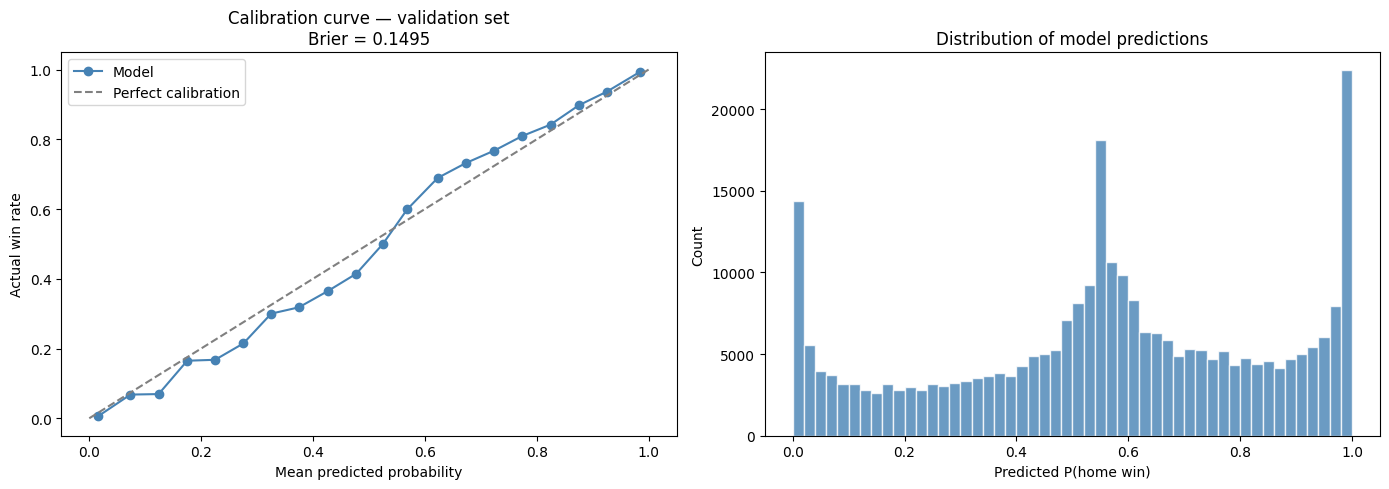

In [198]:
# Calibration plot — model predictions on validation set
val_probs = pbp_all.loc[val_mask, "model_prob"].values
val_true = y_val.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraction_pos, mean_predicted = calibration_curve(val_true, val_probs, n_bins=20)
axes[0].plot(mean_predicted, fraction_pos, "o-", color="steelblue", label="Model")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Actual win rate")
axes[0].set_title(f"Calibration curve — validation set\nBrier = {val_brier:.4f}")
axes[0].legend()

axes[1].hist(val_probs, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Predicted P(home win)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of model predictions")

plt.tight_layout()
plt.show()

## 6. Model vs Kalshi — with and without lag adjustment

Two evaluations on the validation set (games from Feb 1+):

1. **No lag adjustment** — join on raw `timeActual` ↔ `created_time`. This is the "oracle" scenario: you know the play instantly and see all trades instantly.
2. **Lag-adjusted** — simulates a live system. NBA CDN data arrives ~12.0s after the play (median). Kalshi WS data arrives ~0.5s after trade execution (median). For historical trades (no `t_receipt`), we add these constants to simulate ingestion delay.

**Lag math:** When a play happens at time T, we'd see it at T + 12.0s. At that decision point, the latest Kalshi trade we'd have received executed at most at T + 12.0 − 0.5 = T + 11.5s. So we shift `timeActual` forward by 12.0s and `created_time` forward by 0.5s before the `merge_asof`.

In [199]:
# Build game_id → home team Kalshi ticker mapping
game_to_ticker = {}
for et in markets_df["event_ticker"].unique():
    parsed = parse_event_ticker(et)
    if parsed and parsed["game_id"]:
        home_ticker = f"{et}-{parsed['home']}"
        if home_ticker in markets_df["ticker"].values:
            game_to_ticker[parsed["game_id"]] = home_ticker

print(f"{len(game_to_ticker)} games mapped to Kalshi home-team tickers")

# Load trades for all matched games (parallel) — only keep columns we need
def load_trades(ticker):
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{ticker}.json")
        return json.loads(obj["Body"].read())
    except Exception:
        return []

print(f"Loading Kalshi trades...")
all_trades = {}
with ThreadPoolExecutor(max_workers=20) as pool:
    futures = {pool.submit(load_trades, ticker): gid for gid, ticker in game_to_ticker.items()}
    for i, future in enumerate(as_completed(futures)):
        gid = futures[future]
        data = future.result()
        if data:
            tdf = pd.DataFrame(data)[["created_time", "yes_price_dollars"]]  # only keep what we need
            tdf["created_time"] = pd.to_datetime(tdf["created_time"], format="ISO8601", utc=True)
            tdf["yes_price"] = tdf["yes_price_dollars"].astype(np.float32)
            tdf = tdf.drop(columns=["yes_price_dollars"])
            all_trades[gid] = tdf
        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(game_to_ticker)} tickers loaded...")

total_trades = sum(len(df) for df in all_trades.values())
print(f"\nLoaded trades for {len(all_trades)} games ({total_trades:,} total trades)")

861 games mapped to Kalshi home-team tickers
Loading Kalshi trades...
  200/861 tickers loaded...
  400/861 tickers loaded...
  600/861 tickers loaded...
  800/861 tickers loaded...

Loaded trades for 861 games (8,572,570 total trades)


In [200]:
# Join model predictions to Kalshi prices — both with and without lag
NBA_LAG_MEDIAN = pd.Timedelta(seconds=12.0)
KALSHI_LAG_MEDIAN = pd.Timedelta(seconds=0.526)

# Only evaluate on validation set games that have Kalshi trades
val_games = pbp_all[val_mask & pbp_all["game_id"].isin(all_trades)]["game_id"].unique()
print(f"Validation games with Kalshi trades: {len(val_games)}")

results_no_lag = []
results_lag = []

for game_id in val_games:
    group = pbp_all[(pbp_all["game_id"] == game_id) & val_mask].sort_values("timeActual")
    trades = all_trades[game_id][["created_time", "yes_price"]].sort_values("created_time")

    # --- No lag: raw timestamps ---
    joined_raw = pd.merge_asof(
        group, trades,
        left_on="timeActual", right_on="created_time",
        direction="backward",
    )
    joined_raw = joined_raw.rename(columns={"yes_price": "kalshi_prob"})
    results_no_lag.append(joined_raw)

    # --- Lag-adjusted: shift timestamps to simulate live ingestion ---
    group_lag = group.copy()
    group_lag["decision_time"] = group_lag["timeActual"] + NBA_LAG_MEDIAN

    trades_lag = trades.copy()
    trades_lag["receipt_time"] = trades_lag["created_time"] + KALSHI_LAG_MEDIAN

    joined_adj = pd.merge_asof(
        group_lag,
        trades_lag[["receipt_time", "yes_price"]],
        left_on="decision_time", right_on="receipt_time",
        direction="backward",
    )
    joined_adj = joined_adj.rename(columns={"yes_price": "kalshi_prob"})
    results_lag.append(joined_adj)

eval_no_lag = pd.concat(results_no_lag, ignore_index=True)
eval_lag = pd.concat(results_lag, ignore_index=True)

# Downcast float columns
for col in ["kalshi_prob", "model_prob"]:
    if col in eval_no_lag.columns:
        eval_no_lag[col] = eval_no_lag[col].astype(np.float32)
    if col in eval_lag.columns:
        eval_lag[col] = eval_lag[col].astype(np.float32)

print(f"No-lag:      {len(eval_no_lag):,} actions, {eval_no_lag['game_id'].nunique()} games, "
      f"{eval_no_lag['kalshi_prob'].notna().sum():,} with Kalshi price")
print(f"Lag-adjusted: {len(eval_lag):,} actions, {eval_lag['game_id'].nunique()} games, "
      f"{eval_lag['kalshi_prob'].notna().sum():,} with Kalshi price")

del results_no_lag, results_lag, all_trades
gc.collect()
print(f"Freed intermediate join buffers + all_trades (8.5M rows)")

Validation games with Kalshi trades: 95
No-lag:      54,010 actions, 95 games, 54,010 with Kalshi price
Lag-adjusted: 54,010 actions, 95 games, 54,010 with Kalshi price
Freed intermediate join buffers + all_trades (8.5M rows)


In [201]:
# Brier score comparison: model vs Kalshi, both scenarios
print("=" * 70)
print("BRIER SCORE COMPARISON — lower is better")
print("=" * 70)

for label, ev in [("No lag adjustment (oracle)", eval_no_lag),
                   ("Lag-adjusted (realistic)", eval_lag)]:
    valid = ev.dropna(subset=["kalshi_prob", "model_prob"])
    brier_model = brier_score_loss(valid["home_win"], valid["model_prob"])
    brier_kalshi = brier_score_loss(valid["home_win"], valid["kalshi_prob"])
    diff = brier_model - brier_kalshi

    print(f"\n{label}")
    print(f"  {len(valid):,} actions across {valid['game_id'].nunique()} games")
    print(f"  Model Brier:  {brier_model:.4f}")
    print(f"  Kalshi Brier: {brier_kalshi:.4f}")
    print(f"  Delta:        {diff:+.4f} ({'model worse' if diff > 0 else 'model better'})")

BRIER SCORE COMPARISON — lower is better

No lag adjustment (oracle)
  54,010 actions across 95 games
  Model Brier:  0.1693
  Kalshi Brier: 0.1463
  Delta:        +0.0230 (model worse)

Lag-adjusted (realistic)
  54,010 actions across 95 games
  Model Brier:  0.1693
  Kalshi Brier: 0.1458
  Delta:        +0.0236 (model worse)


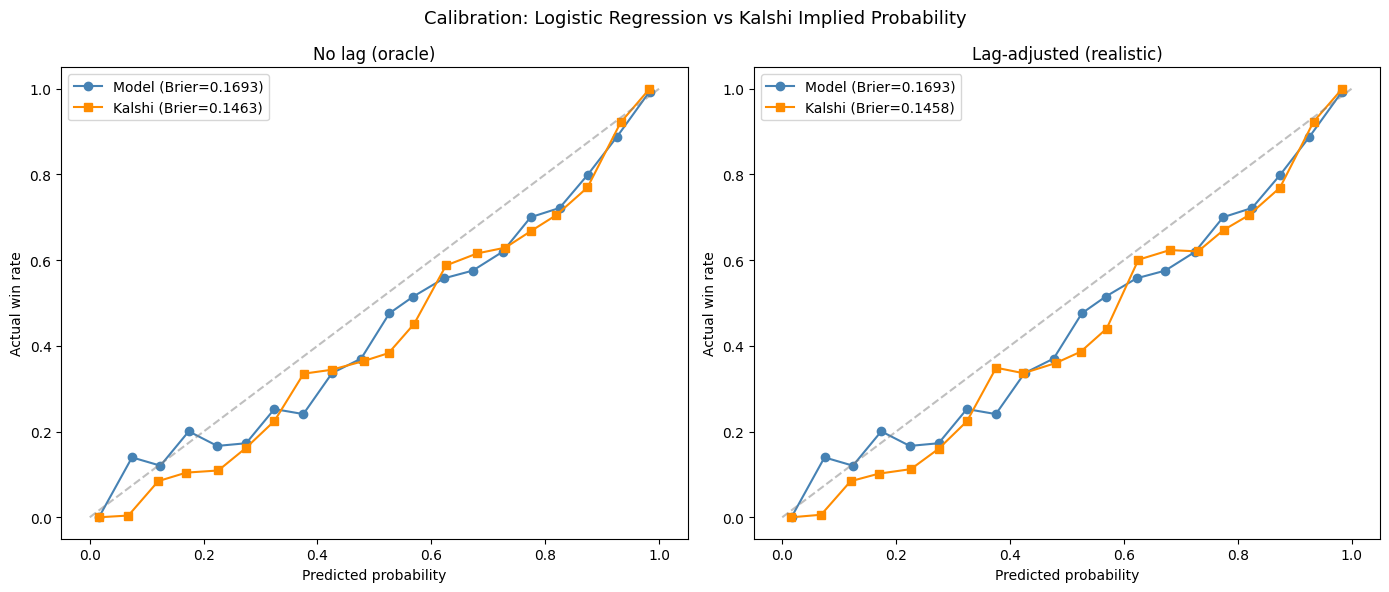

In [202]:
# Calibration: model vs Kalshi, side by side, both scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, ev) in zip(axes, [("No lag (oracle)", eval_no_lag),
                                    ("Lag-adjusted (realistic)", eval_lag)]):
    valid = ev.dropna(subset=["kalshi_prob", "model_prob"])

    frac_m, mean_m = calibration_curve(valid["home_win"], valid["model_prob"], n_bins=20)
    frac_k, mean_k = calibration_curve(valid["home_win"], valid["kalshi_prob"], n_bins=20)

    brier_m = brier_score_loss(valid["home_win"], valid["model_prob"])
    brier_k = brier_score_loss(valid["home_win"], valid["kalshi_prob"])

    ax.plot(mean_m, frac_m, "o-", color="steelblue", label=f"Model (Brier={brier_m:.4f})")
    ax.plot(mean_k, frac_k, "s-", color="darkorange", label=f"Kalshi (Brier={brier_k:.4f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual win rate")
    ax.set_title(label)
    ax.legend()

plt.suptitle("Calibration: Logistic Regression vs Kalshi Implied Probability", fontsize=13)
plt.tight_layout()
plt.show()

In [203]:
# Simulated PnL: trade 1 contract when |model - kalshi| > threshold
# NOTE: this trades at every PBP action independently — overcounts within a game.
# A real strategy would hold a position rather than re-entering at every action.
# This is directional signal only.

EDGE_THRESHOLD = 0.05  # 5-cent minimum edge to trade
KALSHI_FEE = 0.02      # ~2 cents round-trip (taker fee + settlement)

print("=" * 70)
print(f"SIMULATED PnL — edge threshold = {EDGE_THRESHOLD}, fee = {KALSHI_FEE}")
print("=" * 70)

for label, ev in [("No lag (oracle)", eval_no_lag),
                   ("Lag-adjusted (realistic)", eval_lag)]:
    valid = ev.dropna(subset=["kalshi_prob", "model_prob"]).copy()
    valid["edge"] = valid["model_prob"] - valid["kalshi_prob"]

    trades = valid[valid["edge"].abs() > EDGE_THRESHOLD].copy()

    # Buy YES when model says home is underpriced, NO when overpriced
    trades["position"] = np.where(trades["edge"] > 0, "yes", "no")
    trades["entry_price"] = np.where(
        trades["position"] == "yes",
        trades["kalshi_prob"],       # buy yes at market price
        1 - trades["kalshi_prob"],   # buy no at 1 - market price
    )
    trades["payout"] = np.where(
        ((trades["position"] == "yes") & (trades["home_win"] == 1)) |
        ((trades["position"] == "no") & (trades["home_win"] == 0)),
        1.0, 0.0,
    )
    trades["pnl"] = trades["payout"] - trades["entry_price"] - KALSHI_FEE

    n_yes = (trades["position"] == "yes").sum()
    n_no = (trades["position"] == "no").sum()

    print(f"\n{label}")
    print(f"  Signals: {len(trades):,} ({n_yes:,} yes, {n_no:,} no) across {trades['game_id'].nunique()} games")
    print(f"  Win rate:      {(trades['pnl'] > 0).mean():.1%}")
    print(f"  Mean PnL/trade: ${trades['pnl'].mean():.4f}")
    print(f"  Total PnL:      ${trades['pnl'].sum():,.2f}")
    print(f"  Mean |edge|:    {trades['edge'].abs().mean():.3f}")

SIMULATED PnL — edge threshold = 0.05, fee = 0.02

No lag (oracle)
  Signals: 31,749 (13,282 yes, 18,467 no) across 95 games
  Win rate:      29.1%
  Mean PnL/trade: $-0.0528
  Total PnL:      $-1,675.60
  Mean |edge|:    0.158

Lag-adjusted (realistic)
  Signals: 31,788 (13,362 yes, 18,426 no) across 95 games
  Win rate:      28.4%
  Mean PnL/trade: $-0.0570
  Total PnL:      $-1,811.84
  Mean |edge|:    0.157


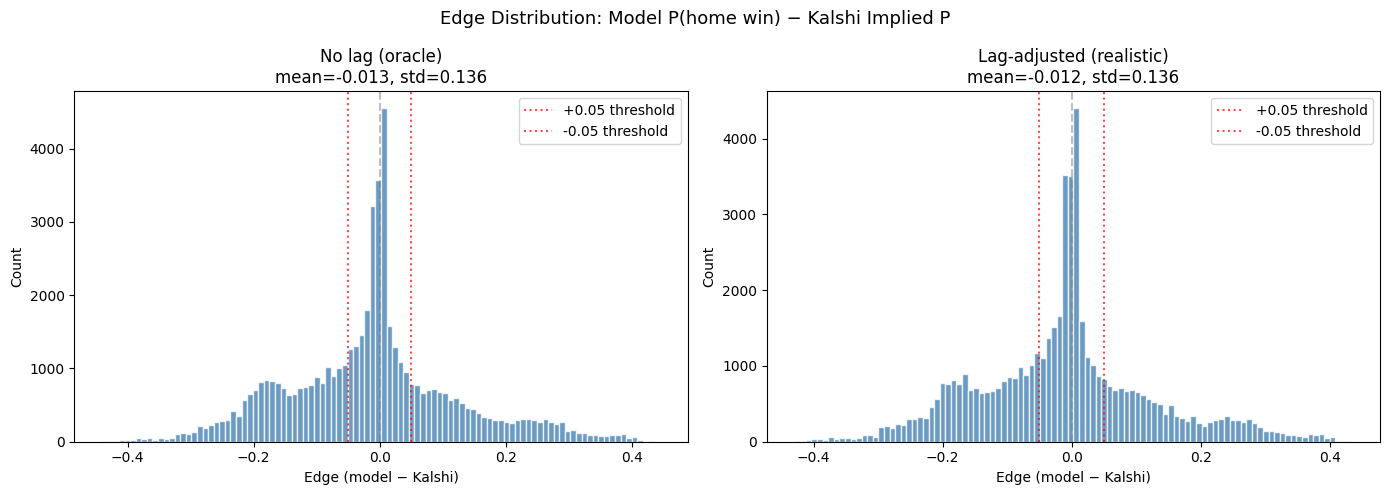

In [204]:
# Edge distribution: model_prob - kalshi_prob (lag-adjusted)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, ev) in zip(axes, [("No lag (oracle)", eval_no_lag),
                                    ("Lag-adjusted (realistic)", eval_lag)]):
    valid = ev.dropna(subset=["kalshi_prob", "model_prob"])
    edge = valid["model_prob"] - valid["kalshi_prob"]

    ax.hist(edge, bins=100, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(EDGE_THRESHOLD, color="red", linestyle=":", alpha=0.7, label=f"+{EDGE_THRESHOLD} threshold")
    ax.axvline(-EDGE_THRESHOLD, color="red", linestyle=":", alpha=0.7, label=f"-{EDGE_THRESHOLD} threshold")
    ax.set_xlabel("Edge (model − Kalshi)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label}\nmean={edge.mean():.3f}, std={edge.std():.3f}")
    ax.legend()

plt.suptitle("Edge Distribution: Model P(home win) − Kalshi Implied P", fontsize=13)
plt.tight_layout()
plt.show()

In [205]:
# --- Memory cleanup: drop DataFrames no longer needed ---
# eval_no_lag was only used for comparison in cells 35-38, eval_lag is the canonical dataset going forward
del eval_no_lag
gc.collect()
print(f"Freed eval_no_lag — using eval_lag only from here on")

Freed eval_no_lag — using eval_lag only from here on


### Realistic backtest — 10% edge threshold, one trade per game

The above PnL overcounts by trading at every PBP action. A real strategy would enter once
and hold to settlement. Below: for each game, take the **first** action where
`|model - kalshi| > 0.10`, enter one contract, hold to expiry.

In [206]:
# Realistic backtest: 10% edge, one trade per game (first signal)
EDGE_THRESHOLD_10 = 0.10
KALSHI_FEE = 0.02

print("=" * 70)
print(f"REALISTIC BACKTEST — edge > {EDGE_THRESHOLD_10}, one trade per game, fee = {KALSHI_FEE}")
print("=" * 70)

valid = eval_lag.dropna(subset=["kalshi_prob", "model_prob"]).copy()
valid["edge"] = valid["model_prob"] - valid["kalshi_prob"]

# First action per game where |edge| > threshold
signals = valid[valid["edge"].abs() > EDGE_THRESHOLD_10].copy()
first_per_game = signals.groupby("game_id").first().reset_index()

first_per_game["position"] = np.where(first_per_game["edge"] > 0, "yes", "no")
first_per_game["entry_price"] = np.where(
    first_per_game["position"] == "yes",
    first_per_game["kalshi_prob"],
    1 - first_per_game["kalshi_prob"],
)
first_per_game["payout"] = np.where(
    ((first_per_game["position"] == "yes") & (first_per_game["home_win"] == 1)) |
    ((first_per_game["position"] == "no") & (first_per_game["home_win"] == 0)),
    1.0, 0.0,
)
first_per_game["pnl"] = first_per_game["payout"] - first_per_game["entry_price"] - KALSHI_FEE

n_yes = (first_per_game["position"] == "yes").sum()
n_no = (first_per_game["position"] == "no").sum()
n_games = len(first_per_game)
n_total_games = eval_lag["game_id"].nunique()

print(f"\nLag-adjusted (realistic)")
print(f"  Games with signal: {n_games}/{n_total_games} ({n_games/n_total_games:.0%})")
print(f"  Positions: {n_yes} yes, {n_no} no")
print(f"  Win rate:       {(first_per_game['pnl'] > 0).mean():.1%}")
print(f"  Mean entry:     ${first_per_game['entry_price'].mean():.3f}")
print(f"  Mean |edge|:    {first_per_game['edge'].abs().mean():.3f}")
print(f"  Mean PnL/trade: ${first_per_game['pnl'].mean():.4f}")
print(f"  Total PnL:      ${first_per_game['pnl'].sum():,.2f}")
if first_per_game['pnl'].std() > 0:
    print(f"  Sharpe (per-trade): {first_per_game['pnl'].mean() / first_per_game['pnl'].std():.2f}")

for pos in ["yes", "no"]:
    subset = first_per_game[first_per_game["position"] == pos]
    if len(subset) > 0:
        print(f"    {pos:3s}: {len(subset):3d} trades, "
              f"win rate {(subset['pnl']>0).mean():.1%}, "
              f"mean PnL ${subset['pnl'].mean():.4f}")

REALISTIC BACKTEST — edge > 0.1, one trade per game, fee = 0.02

Lag-adjusted (realistic)
  Games with signal: 94/95 (99%)
  Positions: 37 yes, 57 no
  Win rate:       29.8%
  Mean entry:     $0.304
  Mean |edge|:    0.192
  Mean PnL/trade: $-0.0264
  Total PnL:      $-2.48
  Sharpe (per-trade): -0.06
    yes:  37 trades, win rate 24.3%, mean PnL $-0.1276
    no :  57 trades, win rate 33.3%, mean PnL $0.0393


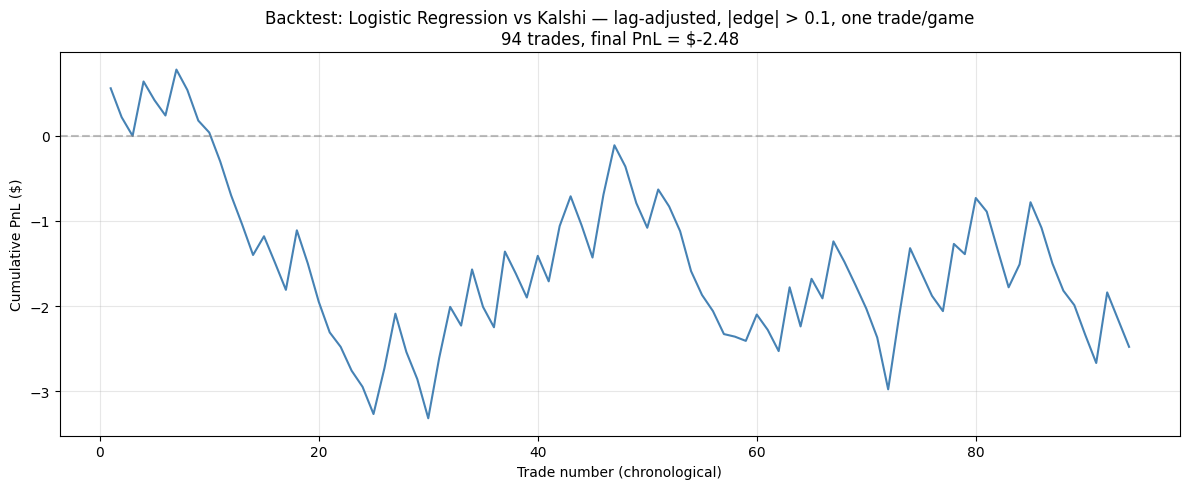

In [207]:
# Cumulative PnL curve — lag-adjusted, 10% threshold, one trade per game
# Uses eval_lag (still available, freed later in cell 50)
valid = eval_lag.dropna(subset=["kalshi_prob", "model_prob"]).copy()
valid["edge"] = valid["model_prob"] - valid["kalshi_prob"]
signals = valid[valid["edge"].abs() > EDGE_THRESHOLD_10]
first_per_game = signals.groupby("game_id").first().reset_index()
first_per_game["position"] = np.where(first_per_game["edge"] > 0, "yes", "no")
first_per_game["entry_price"] = np.where(
    first_per_game["position"] == "yes",
    first_per_game["kalshi_prob"],
    1 - first_per_game["kalshi_prob"],
)
first_per_game["payout"] = np.where(
    ((first_per_game["position"] == "yes") & (first_per_game["home_win"] == 1)) |
    ((first_per_game["position"] == "no") & (first_per_game["home_win"] == 0)),
    1.0, 0.0,
)
first_per_game["pnl"] = first_per_game["payout"] - first_per_game["entry_price"] - KALSHI_FEE
first_per_game = first_per_game.sort_values("timeActual").reset_index(drop=True)
first_per_game["cumulative_pnl"] = first_per_game["pnl"].cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(first_per_game) + 1), first_per_game["cumulative_pnl"],
        color="steelblue", linewidth=1.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Trade number (chronological)")
ax.set_ylabel("Cumulative PnL ($)")
ax.set_title(f"Backtest: Logistic Regression vs Kalshi — lag-adjusted, "
             f"|edge| > {EDGE_THRESHOLD_10}, one trade/game\n"
             f"{len(first_per_game)} trades, final PnL = ${first_per_game['cumulative_pnl'].iloc[-1]:.2f}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Engineering — Progressive Complexity

The baseline logistic regression (margin + time + interaction) has Brier 0.1693 vs Kalshi's 0.1463.
It loses money because of a systematic home bias. Let's fix that and layer in better features.

**Tiers:**
1. Pre-game team strength (fix the bias)
2. Stern leverage term: `margin / √(seconds_remaining)` + period
3. Momentum & pace (scoring runs, action density)
4. XGBoost with all features

In [208]:
# --- Tier 1: Pre-game team strength ---
# Compute each team's win% prior to each game (no lookahead)

# Get one row per game with outcome + teams
game_outcomes = pbp_all.groupby("game_id").first()[["timeActual", "home_win"]].reset_index()
game_outcomes = game_outcomes.merge(
    df[["game_id", "home_team", "away_team"]].drop_duplicates(),
    on="game_id", how="left"
)
game_outcomes = game_outcomes.sort_values("timeActual").reset_index(drop=True)

# Build cumulative win record for each team up to (but not including) each game
team_wins = {}   # team -> list of (game_idx, won_bool)
home_wp = []     # pre-game home team win%
away_wp = []     # pre-game away team win%

for idx, row in game_outcomes.iterrows():
    ht, at = row["home_team"], row["away_team"]

    # Home team prior record
    if ht in team_wins and len(team_wins[ht]) > 0:
        h_record = team_wins[ht]
        home_wp.append(sum(h_record) / len(h_record))
    else:
        home_wp.append(0.5)  # no prior games → 0.5

    # Away team prior record
    if at in team_wins and len(team_wins[at]) > 0:
        a_record = team_wins[at]
        away_wp.append(sum(a_record) / len(a_record))
    else:
        away_wp.append(0.5)

    # Update records after computing prior
    team_wins.setdefault(ht, []).append(1 if row["home_win"] == 1 else 0)
    team_wins.setdefault(at, []).append(1 if row["home_win"] == 0 else 0)

game_outcomes["home_wp"] = home_wp
game_outcomes["away_wp"] = away_wp
game_outcomes["wp_diff"] = game_outcomes["home_wp"] - game_outcomes["away_wp"]

print(f"Team strength computed for {len(game_outcomes)} games")
print(f"Mean home_wp: {game_outcomes['home_wp'].mean():.3f}, mean away_wp: {game_outcomes['away_wp'].mean():.3f}")
print(f"wp_diff range: [{game_outcomes['wp_diff'].min():.3f}, {game_outcomes['wp_diff'].max():.3f}]")
game_outcomes[["game_id", "home_team", "away_team", "home_wp", "away_wp", "wp_diff", "home_win"]].head(10)

Team strength computed for 1230 games
Mean home_wp: 0.500, mean away_wp: 0.499
wp_diff range: [-1.000, 1.000]


,game_id,home_team,away_team,home_wp,away_wp,wp_diff,home_win
0,0022500001,OKC,HOU,0.5,0.5,0.0,1
1,0022500002,LAL,GSW,0.5,0.5,0.0,0
2,0022500080,CHA,BKN,0.5,0.5,0.0,1
3,0022500003,NYK,CLE,0.5,0.5,0.0,1
4,0022500081,ORL,MIA,0.5,0.5,0.0,1
5,0022500083,BOS,PHI,0.5,0.5,0.0,0
6,0022500082,ATL,TOR,0.5,0.5,0.0,0
7,0022500085,MEM,NOP,0.5,0.5,0.0,1
8,0022500086,MIL,WAS,0.5,0.5,0.0,1
9,0022500084,CHI,DET,0.5,0.5,0.0,1


In [209]:
# --- Tier 2 & 3: Build all features on pbp_all ---

# Merge pre-game team strength into pbp_all
pbp_all = pbp_all.merge(
    game_outcomes[["game_id", "home_wp", "away_wp", "wp_diff"]],
    on="game_id", how="left"
)

# Tier 2: Stern leverage term — margin / sqrt(time)
# When seconds_remaining = 0, use a small epsilon to avoid division by zero
pbp_all["leverage"] = pbp_all["margin"] / np.sqrt(pbp_all["seconds_remaining"].clip(lower=1))

# Tier 3: Momentum — scoring run over last N actions within each game
# Compute rolling margin delta: how much has the margin changed in the last 10 actions?
pbp_all = pbp_all.sort_values(["game_id", "timeActual"]).reset_index(drop=True)
pbp_all["margin_shift_10"] = pbp_all.groupby("game_id")["margin"].transform(
    lambda x: x - x.shift(10, fill_value=0)
)

# Tier 3: Pace proxy — actions per minute in the last 2 minutes of game time
# Use rolling count of actions in last 120 seconds of wall-clock time
# Simplified: actions in last 20 rows as a density proxy
pbp_all["action_density"] = pbp_all.groupby("game_id")["margin"].transform(
    lambda x: pd.Series(range(len(x)), index=x.index).rolling(20, min_periods=1).count()
) / 20  # normalized to ~1.0

# Recompute interaction term (in case merge reordered)
pbp_all["margin_x_time"] = pbp_all["margin"] * pbp_all["seconds_remaining"]

print("Features built:")
print(f"  wp_diff range: [{pbp_all['wp_diff'].min():.3f}, {pbp_all['wp_diff'].max():.3f}]")
print(f"  leverage range: [{pbp_all['leverage'].min():.2f}, {pbp_all['leverage'].max():.2f}]")
print(f"  margin_shift_10 range: [{pbp_all['margin_shift_10'].min()}, {pbp_all['margin_shift_10'].max()}]")
print(f"  action_density mean: {pbp_all['action_density'].mean():.3f}")
pbp_all[["margin", "seconds_remaining", "wp_diff", "leverage", "margin_shift_10", "period"]].describe()

Features built:
  wp_diff range: [-1.000, 1.000]
  leverage range: [-55.00, 54.00]
  margin_shift_10 range: [-16, 13]
  action_density mean: 0.984


,margin,seconds_remaining,wp_diff,leverage,margin_shift_10,period
count,708266.000000,708266.000000,708266.000000,708266.000000,708266.000000,708266.000000
mean,0.906690,1398.957520,0.000360,0.048125,0.030771,2.545380
std,12.211027,825.950867,0.276527,1.255996,2.360976,1.125797
min,-57.000000,0.000000,-1.000000,-55.000000,-16.000000,1.000000
25%,-6.000000,720.000000,-0.166667,-0.175581,-2.000000,2.000000
50%,1.000000,1440.000000,0.000000,0.019615,0.000000,3.000000
75%,8.000000,2135.000000,0.176471,0.232057,2.000000,4.000000
max,59.000000,2880.000000,1.000000,54.000000,13.000000,6.000000


In [210]:
# --- Train all model tiers and compare ---
# Redefine train/val masks (same split date)
train_mask = pbp_all["timeActual"] < SPLIT_DATE
val_mask = pbp_all["timeActual"] >= SPLIT_DATE
y_train = pbp_all.loc[train_mask, "home_win"]
y_val = pbp_all.loc[val_mask, "home_win"]

# Define feature sets for each tier
tiers = {
    "T0: Baseline (margin + time)": ["margin", "seconds_remaining", "margin_x_time"],
    "T1: + Team strength": ["margin", "seconds_remaining", "margin_x_time", "wp_diff"],
    "T2: + Leverage (Stern)": ["margin", "seconds_remaining", "wp_diff", "leverage"],
    "T3: + Momentum & pace": ["margin", "seconds_remaining", "wp_diff", "leverage",
                               "margin_shift_10", "action_density"],
}

results = {}
for name, features in tiers.items():
    lr = LogisticRegression(max_iter=1000)
    lr.fit(pbp_all.loc[train_mask, features], y_train)
    pred = lr.predict_proba(pbp_all.loc[val_mask, features])[:, 1]
    brier = brier_score_loss(y_val, pred)
    results[name] = {"brier": brier, "model": lr, "features": features, "preds": pred}

# Print comparison table
print(f"{'Model':<35} {'Brier':>8} {'vs Kalshi':>10}")
print("-" * 55)
kalshi_brier = 0.1463  # from earlier evaluation
for name, r in results.items():
    diff = r["brier"] - kalshi_brier
    print(f"{name:<35} {r['brier']:.4f}   {diff:+.4f}")
print(f"{'Kalshi implied':<35} {kalshi_brier:.4f}   {'(baseline)':>10}")

# Show T1 coefficients to verify bias is fixed
print(f"\nT1 coefficients:")
t1 = results["T1: + Team strength"]
for feat, coef in zip(t1["features"], t1["model"].coef_[0]):
    print(f"  {feat:25s} {coef:+.6f}")
print(f"  {'intercept':25s} {t1['model'].intercept_[0]:+.6f}")

Model                                  Brier  vs Kalshi
-------------------------------------------------------
T0: Baseline (margin + time)        0.1495   +0.0032
T1: + Team strength                 0.1342   -0.0121
T2: + Leverage (Stern)              0.1322   -0.0141
T3: + Momentum & pace               0.1322   -0.0141
Kalshi implied                      0.1463   (baseline)

T1 coefficients:
  margin                    +0.263767
  seconds_remaining         -0.000004
  margin_x_time             -0.000090
  wp_diff                   +1.561071
  intercept                 +0.237149


In [211]:
# --- Tier 4: XGBoost ---
xgb_features = ["margin", "seconds_remaining", "wp_diff", "leverage",
                 "margin_shift_10", "action_density", "period"]

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
xgb.fit(pbp_all.loc[train_mask, xgb_features], y_train, verbose=False)
xgb_pred = xgb.predict_proba(pbp_all.loc[val_mask, xgb_features])[:, 1]
xgb_brier = brier_score_loss(y_val, xgb_pred)

results["T4: XGBoost"] = {"brier": xgb_brier, "model": xgb, "features": xgb_features, "preds": xgb_pred}

# Final comparison table
print(f"\n{'Model':<35} {'Brier':>8} {'vs Kalshi':>10} {'Improvement':>12}")
print("=" * 70)
baseline_brier = results["T0: Baseline (margin + time)"]["brier"]
for name, r in results.items():
    diff_k = r["brier"] - kalshi_brier
    diff_b = r["brier"] - baseline_brier
    print(f"{name:<35} {r['brier']:.4f}   {diff_k:+.4f}     {diff_b:+.4f}")
print(f"{'Kalshi implied':<35} {kalshi_brier:.4f}   {'---':>10}     {kalshi_brier - baseline_brier:+.4f}")

# Feature importance for XGBoost
print(f"\nXGBoost feature importance:")
for feat, imp in sorted(zip(xgb_features, xgb.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat:25s} {imp:.3f}")


Model                                  Brier  vs Kalshi  Improvement
T0: Baseline (margin + time)        0.1495   +0.0032     +0.0000
T1: + Team strength                 0.1342   -0.0121     -0.0152
T2: + Leverage (Stern)              0.1322   -0.0141     -0.0172
T3: + Momentum & pace               0.1322   -0.0141     -0.0172
T4: XGBoost                         0.1411   -0.0052     -0.0084
Kalshi implied                      0.1463          ---     -0.0032

XGBoost feature importance:
  leverage                  0.551
  margin                    0.212
  wp_diff                   0.173
  seconds_remaining         0.034
  period                    0.020
  action_density            0.006
  margin_shift_10           0.004


In [212]:
# --- Backtest all tiers at 10% threshold (one trade/game, lag-adjusted) ---
# Build eval_enriched ONCE (replaces eval_lag with features added in-place)
def add_features_inplace(ev):
    ev = ev.merge(game_outcomes[["game_id", "wp_diff"]], on="game_id", how="left")
    ev["leverage"] = ev["margin"] / np.sqrt(ev["seconds_remaining"].clip(lower=1))
    ev = ev.sort_values(["game_id", "timeActual"]).reset_index(drop=True)
    ev["margin_shift_10"] = ev.groupby("game_id")["margin"].transform(
        lambda x: x - x.shift(10, fill_value=0)
    )
    ev["action_density"] = ev.groupby("game_id")["margin"].transform(
        lambda x: pd.Series(range(len(x)), index=x.index).rolling(20, min_periods=1).count()
    ) / 20
    ev["margin_x_time"] = ev["margin"] * ev["seconds_remaining"]
    return ev

eval_enriched = add_features_inplace(eval_lag)
del eval_lag  # eval_enriched IS the canonical dataset now
gc.collect()

print(f"{"Model":<35} {"Trades":>6} {"Win%":>6} {"PnL/trade":>10} {"Total PnL":>10} {"Sharpe":>7}")
print("=" * 80)

for name, r in results.items():
    ev = eval_enriched.copy()
    ev["model_prob"] = r["model"].predict_proba(ev[r["features"]])[:, 1]
    valid = ev.dropna(subset=["kalshi_prob"]).copy()
    valid["edge"] = valid["model_prob"] - valid["kalshi_prob"]

    signals = valid[valid["edge"].abs() > EDGE_THRESHOLD_10]
    fpg = signals.groupby("game_id").first().reset_index()

    fpg["position"] = np.where(fpg["edge"] > 0, "yes", "no")
    fpg["entry_price"] = np.where(fpg["position"] == "yes", fpg["kalshi_prob"], 1 - fpg["kalshi_prob"])
    fpg["payout"] = np.where(
        ((fpg["position"] == "yes") & (fpg["home_win"] == 1)) |
        ((fpg["position"] == "no") & (fpg["home_win"] == 0)),
        1.0, 0.0,
    )
    fpg["pnl"] = fpg["payout"] - fpg["entry_price"] - KALSHI_FEE

    n = len(fpg)
    wr = (fpg["pnl"] > 0).mean() if n > 0 else 0
    mean_pnl = fpg["pnl"].mean() if n > 0 else 0
    total_pnl = fpg["pnl"].sum() if n > 0 else 0
    sharpe = fpg["pnl"].mean() / fpg["pnl"].std() if n > 0 and fpg["pnl"].std() > 0 else 0

    print(f"{name:<35} {n:>6} {wr:>5.1%} {mean_pnl:>+10.4f} {total_pnl:>+10.2f} {sharpe:>+7.2f}")

Model                               Trades   Win%  PnL/trade  Total PnL  Sharpe
T0: Baseline (margin + time)            94 29.8%    -0.0264      -2.48   -0.06
T1: + Team strength                     92 26.1%    -0.0634      -5.83   -0.15
T2: + Leverage (Stern)                  85 30.6%    -0.0338      -2.87   -0.08
T3: + Momentum & pace                   85 30.6%    -0.0320      -2.72   -0.07
T4: XGBoost                             87 33.3%    -0.0421      -3.66   -0.09


In [213]:
# --- Backtest best model vs Kalshi (10% threshold, one trade/game, lag-adjusted) ---
best_name = min(results, key=lambda k: results[k]["brier"])
best = results[best_name]
print(f"Best model: {best_name} (Brier = {best['brier']:.4f})")

best_model = best["model"]
best_features = best["features"]

# Use eval_enriched (already has all features from cell above)
eval_lag_v2 = eval_enriched.copy()
eval_lag_v2["model_prob"] = best_model.predict_proba(eval_lag_v2[best_features])[:, 1]

# 10% threshold, one trade per game
valid = eval_lag_v2.dropna(subset=["kalshi_prob", "model_prob"]).copy()
valid["edge"] = valid["model_prob"] - valid["kalshi_prob"]
signals = valid[valid["edge"].abs() > EDGE_THRESHOLD_10]
first_per_game = signals.groupby("game_id").first().reset_index()

first_per_game["position"] = np.where(first_per_game["edge"] > 0, "yes", "no")
first_per_game["entry_price"] = np.where(
    first_per_game["position"] == "yes",
    first_per_game["kalshi_prob"],
    1 - first_per_game["kalshi_prob"],
)
first_per_game["payout"] = np.where(
    ((first_per_game["position"] == "yes") & (first_per_game["home_win"] == 1)) |
    ((first_per_game["position"] == "no") & (first_per_game["home_win"] == 0)),
    1.0, 0.0,
)
first_per_game["pnl"] = first_per_game["payout"] - first_per_game["entry_price"] - KALSHI_FEE

print(f"\nBACKTEST: {best_name} — lag-adjusted, |edge| > 10%, one trade/game")
print("=" * 70)
print(f"  Games with signal: {len(first_per_game)}/{eval_lag_v2['game_id'].nunique()}")
print(f"  Positions: {(first_per_game['position']=='yes').sum()} yes, "
      f"{(first_per_game['position']=='no').sum()} no")
print(f"  Win rate:       {(first_per_game['pnl'] > 0).mean():.1%}")
print(f"  Mean |edge|:    {first_per_game['edge'].abs().mean():.3f}")
print(f"  Mean PnL/trade: ${first_per_game['pnl'].mean():.4f}")
print(f"  Total PnL:      ${first_per_game['pnl'].sum():,.2f}")
if first_per_game['pnl'].std() > 0:
    print(f"  Sharpe:         {first_per_game['pnl'].mean() / first_per_game['pnl'].std():.2f}")

brier_best = brier_score_loss(valid["home_win"], valid["model_prob"])
brier_kalshi_eval = brier_score_loss(valid["home_win"], valid["kalshi_prob"])
print(f"\n  Model Brier (Kalshi games): {brier_best:.4f}")
print(f"  Kalshi Brier:               {brier_kalshi_eval:.4f}")
print(f"  Gap:                        {brier_best - brier_kalshi_eval:+.4f}")

del eval_lag_v2
gc.collect()

Best model: T2: + Leverage (Stern) (Brier = 0.1322)

BACKTEST: T2: + Leverage (Stern) — lag-adjusted, |edge| > 10%, one trade/game
  Games with signal: 85/95
  Positions: 38 yes, 47 no
  Win rate:       30.6%
  Mean |edge|:    0.152
  Mean PnL/trade: $-0.0338
  Total PnL:      $-2.87
  Sharpe:         -0.08

  Model Brier (Kalshi games): 0.1569
  Kalshi Brier:               0.1458
  Gap:                        +0.0111


0

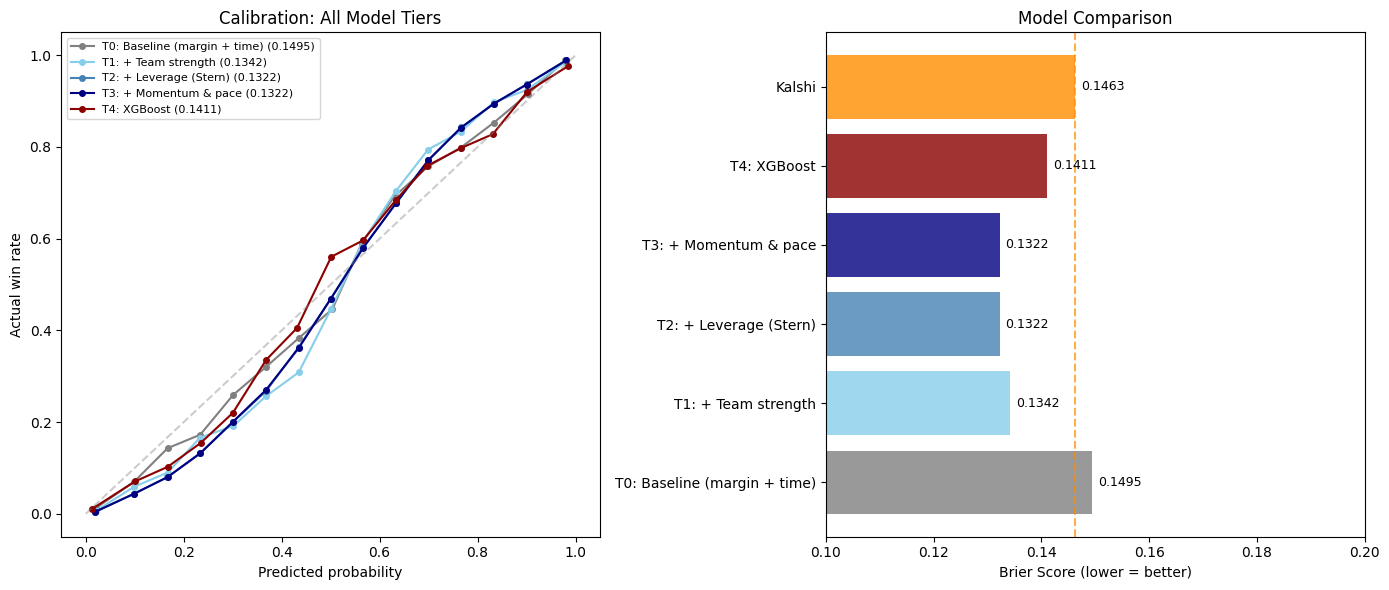

In [214]:
# --- Calibration comparison: all tiers + Kalshi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: calibration curves for all models
ax = axes[0]
colors = ["gray", "skyblue", "steelblue", "navy", "darkred"]
for (name, r), color in zip(results.items(), colors):
    frac, mean_p = calibration_curve(y_val, r["preds"], n_bins=15)
    ax.plot(mean_p, frac, "o-", color=color, markersize=4,
            label=f"{name} ({r['brier']:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.4)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual win rate")
ax.set_title("Calibration: All Model Tiers")
ax.legend(fontsize=8)

# Right: Brier score bar chart
ax = axes[1]
names = list(results.keys()) + ["Kalshi"]
briers = [r["brier"] for r in results.values()] + [kalshi_brier]
bar_colors = colors + ["darkorange"]
bars = ax.barh(names, briers, color=bar_colors, alpha=0.8)
ax.axvline(kalshi_brier, color="darkorange", linestyle="--", alpha=0.7, label="Kalshi")
ax.set_xlabel("Brier Score (lower = better)")
ax.set_title("Model Comparison")
ax.set_xlim(0.10, 0.20)
for bar, b in zip(bars, briers):
    ax.text(b + 0.001, bar.get_y() + bar.get_height()/2, f"{b:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Realistic Backtest — Entry/Exit on Edge Convergence

Previous backtests hold to expiry (game end). In reality, we should **exit when our edge disappears** — i.e., when `|model_prob - kalshi_prob| < 10%` again.

**Strategy logic per game:**
1. **Entry**: first action where `|edge| > 10%` → buy YES or NO at Kalshi price
2. **Exit**: first subsequent action where `|edge| <= 10%` → sell at current Kalshi price
3. **Fallback**: if edge never converges → hold to expiry (settle at 0 or 1)

PnL = exit_price - entry_price - fee (for YES), or the inverse for NO.
This is a mean-reversion bet: we enter when model and market diverge, exit when they converge.

In [215]:
# --- Entry/Exit backtest: exit when edge converges back within 10% ---
ENTRY_THRESHOLD = 0.10
EXIT_THRESHOLD = 0.10  # exit when |edge| drops below this
KALSHI_FEE = 0.02      # total round-trip fee

# Use best model (T3) predictions on eval_enriched
ev = eval_enriched.copy()
best_model = results["T3: + Momentum & pace"]["model"]
best_features = results["T3: + Momentum & pace"]["features"]
ev["model_prob"] = best_model.predict_proba(ev[best_features])[:, 1]

trades_list = []

for game_id, game_df in ev.groupby("game_id"):
    game_df = game_df.sort_values("timeActual").reset_index(drop=True)
    if game_df["kalshi_prob"].isna().all():
        continue
    
    position = None  # None, "yes", or "no"
    entry_price = None
    entry_idx = None
    entry_edge = None
    
    for i, row in game_df.iterrows():
        kp = row["kalshi_prob"]
        mp = row["model_prob"]
        if pd.isna(kp) or pd.isna(mp):
            continue
        
        edge = mp - kp
        
        if position is None:
            # Check entry condition
            if abs(edge) > ENTRY_THRESHOLD:
                position = "yes" if edge > 0 else "no"
                entry_price = kp if position == "yes" else (1 - kp)
                entry_idx = i
                entry_edge = edge
        else:
            # Check exit condition: edge converged
            if abs(edge) <= EXIT_THRESHOLD:
                # Exit at current market price
                if position == "yes":
                    exit_price = kp  # sell yes at current yes price
                    pnl = exit_price - entry_price - KALSHI_FEE
                else:
                    exit_price = 1 - kp  # sell no at current no price
                    pnl = exit_price - entry_price - KALSHI_FEE
                
                trades_list.append({
                    "game_id": game_id,
                    "position": position,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "entry_edge": entry_edge,
                    "pnl": pnl,
                    "exit_type": "convergence",
                    "hold_actions": i - entry_idx,
                    "home_win": row["home_win"],
                    "entry_time": game_df.loc[entry_idx, "timeActual"],
                    "exit_time": row["timeActual"],
                })
                position = None
                entry_price = None
    
    # If still holding at end of game -> settle at expiry
    if position is not None:
        last_row = game_df.iloc[-1]
        if position == "yes":
            payout = 1.0 if last_row["home_win"] == 1 else 0.0
        else:
            payout = 1.0 if last_row["home_win"] == 0 else 0.0
        pnl = payout - entry_price - KALSHI_FEE
        
        trades_list.append({
            "game_id": game_id,
            "position": position,
            "entry_price": entry_price,
            "exit_price": payout,
            "entry_edge": entry_edge,
            "pnl": pnl,
            "exit_type": "expiry",
            "hold_actions": len(game_df) - entry_idx,
            "home_win": last_row["home_win"],
            "entry_time": game_df.loc[entry_idx, "timeActual"],
            "exit_time": last_row["timeActual"],
        })

trades_df = pd.DataFrame(trades_list)
print(f"ENTRY/EXIT BACKTEST - T3 model, entry |edge| > {ENTRY_THRESHOLD}, exit |edge| < {EXIT_THRESHOLD}")
print("=" * 70)
print(f"  Total trades: {len(trades_df)} across {trades_df['game_id'].nunique()} games")
print(f"  Exit by convergence: {(trades_df['exit_type']=='convergence').sum()}")
print(f"  Exit by expiry:      {(trades_df['exit_type']=='expiry').sum()}")
print(f"  Positions: {(trades_df['position']=='yes').sum()} yes, {(trades_df['position']=='no').sum()} no")
n_win = (trades_df['pnl'] > 0).sum()
print(f"\n  Win rate:       {n_win}/{len(trades_df)} ({n_win/len(trades_df):.1%})")
print(f"  Mean PnL/trade: ${trades_df['pnl'].mean():.4f}")
print(f"  Total PnL:      ${trades_df['pnl'].sum():,.2f}")
if trades_df['pnl'].std() > 0:
    print(f"  Sharpe:         {trades_df['pnl'].mean() / trades_df['pnl'].std():.2f}")
print(f"  Mean hold (actions): {trades_df['hold_actions'].mean():.0f}")

# Breakdown by exit type
print(f"\n  By exit type:")
for etype in ["convergence", "expiry"]:
    sub = trades_df[trades_df["exit_type"] == etype]
    if len(sub) > 0:
        wr = (sub['pnl']>0).mean()
        print(f"    {etype:12s}: {len(sub):3d} trades, win {wr:.1%}, "
              f"mean PnL ${sub['pnl'].mean():.4f}, total ${sub['pnl'].sum():.2f}")

# Breakdown by position
print(f"\n  By position:")
for pos in ["yes", "no"]:
    sub = trades_df[trades_df["position"] == pos]
    if len(sub) > 0:
        wr = (sub['pnl']>0).mean()
        print(f"    {pos:3s}: {len(sub):3d} trades, win {wr:.1%}, "
              f"mean PnL ${sub['pnl'].mean():.4f}, total ${sub['pnl'].sum():.2f}")

ENTRY/EXIT BACKTEST - T3 model, entry |edge| > 0.1, exit |edge| < 0.1
  Total trades: 1347 across 85 games
  Exit by convergence: 1347
  Exit by expiry:      0
  Positions: 621 yes, 726 no

  Win rate:       395/1347 (29.3%)
  Mean PnL/trade: $-0.0122
  Total PnL:      $-16.46
  Sharpe:         -0.19
  Mean hold (actions): 10

  By exit type:
    convergence : 1347 trades, win 29.3%, mean PnL $-0.0122, total $-16.46

  By position:
    yes: 621 trades, win 31.7%, mean PnL $-0.0149, total $-9.26
    no : 726 trades, win 27.3%, mean PnL $-0.0099, total $-7.20


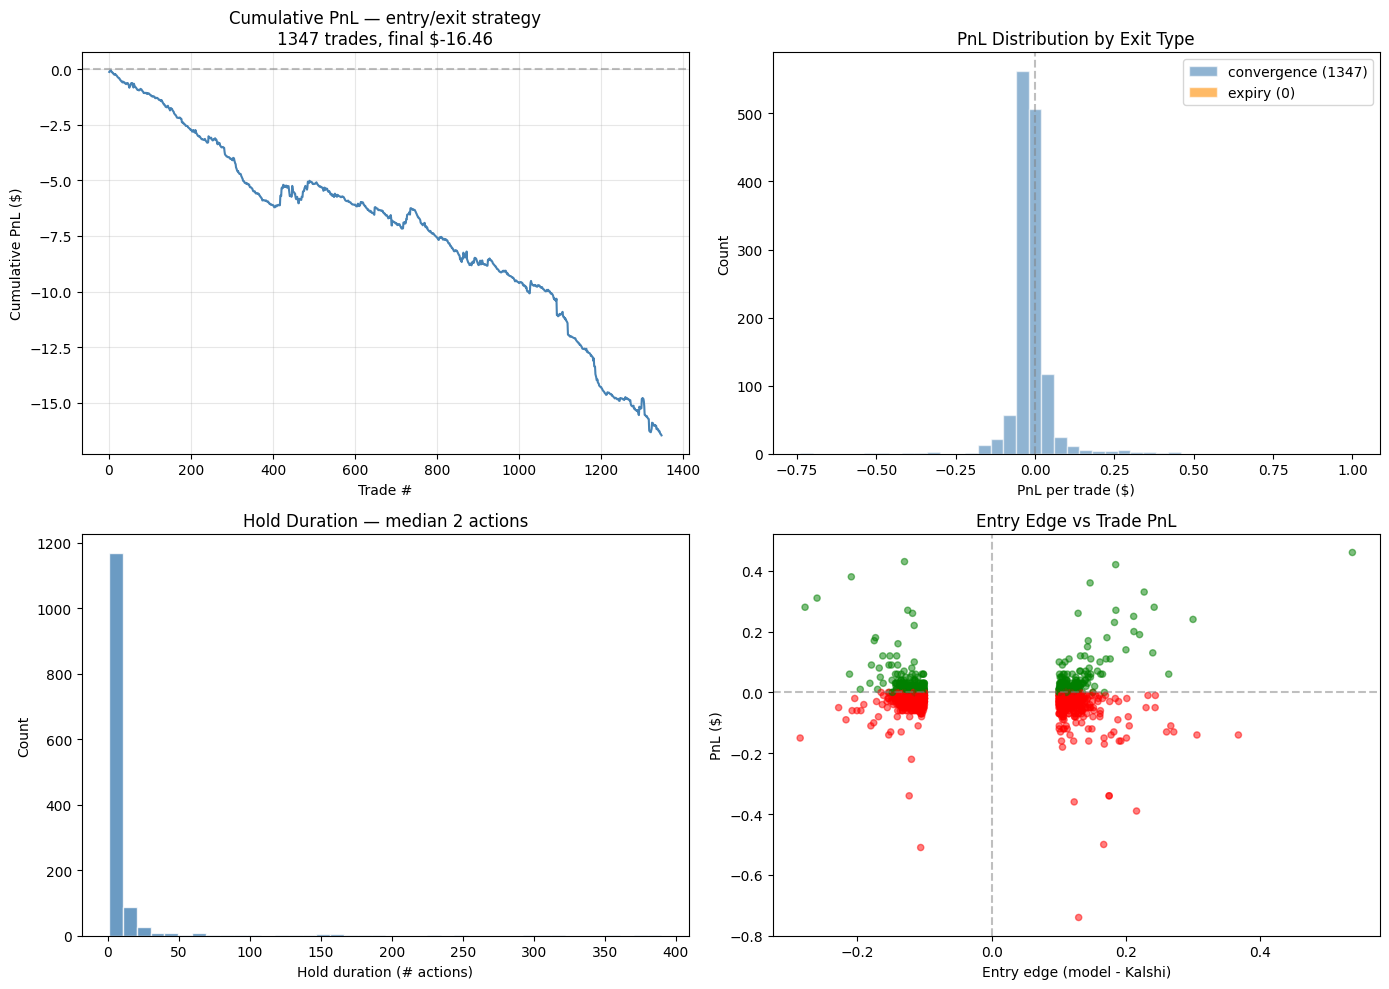

In [216]:
# Cumulative PnL + trade distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: cumulative PnL
trades_sorted = trades_df.sort_values("entry_time").reset_index(drop=True)
trades_sorted["cum_pnl"] = trades_sorted["pnl"].cumsum()
ax = axes[0, 0]
ax.plot(range(1, len(trades_sorted)+1), trades_sorted["cum_pnl"], color="steelblue", lw=1.5)
ax.axhline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative PnL ($)")
ax.set_title(f"Cumulative PnL — entry/exit strategy\n{len(trades_sorted)} trades, final ${trades_sorted['cum_pnl'].iloc[-1]:.2f}")
ax.grid(alpha=0.3)

# Top-right: PnL by exit type
ax = axes[0, 1]
for etype, color in [("convergence", "steelblue"), ("expiry", "darkorange")]:
    sub = trades_sorted[trades_sorted["exit_type"] == etype]
    ax.hist(sub["pnl"], bins=30, alpha=0.6, color=color, label=f"{etype} ({len(sub)})", edgecolor="white")
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("PnL per trade ($)")
ax.set_ylabel("Count")
ax.set_title("PnL Distribution by Exit Type")
ax.legend()

# Bottom-left: hold duration
ax = axes[1, 0]
ax.hist(trades_df["hold_actions"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Hold duration (# actions)")
ax.set_ylabel("Count")
ax.set_title(f"Hold Duration — median {trades_df['hold_actions'].median():.0f} actions")

# Bottom-right: entry edge vs PnL
ax = axes[1, 1]
colors = ["green" if p > 0 else "red" for p in trades_df["pnl"]]
ax.scatter(trades_df["entry_edge"], trades_df["pnl"], c=colors, alpha=0.5, s=20)
ax.axhline(0, color="gray", ls="--", alpha=0.5)
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Entry edge (model - Kalshi)")
ax.set_ylabel("PnL ($)")
ax.set_title("Entry Edge vs Trade PnL")

plt.tight_layout()
plt.show()

## 9. Improved Strategies

The entry/exit backtest revealed that our model loses on the exact moments it disagrees most
with Kalshi (adverse selection). The 10% "edge" is actually the model being slow to incorporate
information the market already has.

Three approaches to fix this:
- **A) Staleness filter** — don't trade when Kalshi price is moving fast (our stale data is worst then)
- **B) Price direction model** — predict where Kalshi's price goes next, not who wins the game
- **C) Strict entry** — higher threshold (20%), first half only, one trade per game, price stability required

In [217]:
# --- Strategy A+C: Staleness filter + strict entry ---
# Conditions:
#   1. |edge| > 20% (high conviction only)
#   2. Kalshi price hasn't moved > 3 cents in last 5 actions (price stable)
#   3. First half only (period <= 2) — model features most reliable early
#   4. One trade per game max
#   5. Exit when |edge| < 10%

ENTRY_EDGE = 0.20
EXIT_EDGE = 0.10
STALE_THRESHOLD = 0.03  # max Kalshi price movement in lookback window
LOOKBACK = 5            # actions to check for price stability
KALSHI_FEE = 0.02

ev = eval_enriched.copy()
best_model = results["T3: + Momentum & pace"]["model"]
best_features = results["T3: + Momentum & pace"]["features"]
ev["model_prob"] = best_model.predict_proba(ev[best_features])[:, 1]

trades_strict = []

for game_id, game_df in ev.groupby("game_id"):
    game_df = game_df.sort_values("timeActual").reset_index(drop=True)
    if game_df["kalshi_prob"].isna().all():
        continue
    
    position = None
    entry_price = None
    entry_idx = None
    traded_this_game = False
    
    for i, row in game_df.iterrows():
        kp = row["kalshi_prob"]
        mp = row["model_prob"]
        if pd.isna(kp) or pd.isna(mp):
            continue
        
        edge = mp - kp
        
        if position is None:
            if traded_this_game:
                continue  # one trade per game
            if abs(edge) <= ENTRY_EDGE:
                continue
            if row["period"] > 2:
                continue  # first half only
            
            # Staleness filter: check if Kalshi price was stable in recent actions
            if i >= LOOKBACK:
                recent_prices = game_df.loc[i-LOOKBACK:i-1, "kalshi_prob"].dropna()
                if len(recent_prices) >= 2:
                    price_range = recent_prices.max() - recent_prices.min()
                    if price_range > STALE_THRESHOLD:
                        continue  # price moving too fast, skip
            
            # Entry
            position = "yes" if edge > 0 else "no"
            entry_price = kp if position == "yes" else (1 - kp)
            entry_idx = i
            entry_edge = edge
            traded_this_game = True
            
        else:
            # Exit when edge converges
            if abs(edge) <= EXIT_EDGE:
                if position == "yes":
                    exit_price = kp
                else:
                    exit_price = 1 - kp
                pnl = exit_price - entry_price - KALSHI_FEE
                
                trades_strict.append({
                    "game_id": game_id, "position": position,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "entry_edge": entry_edge, "pnl": pnl,
                    "exit_type": "convergence",
                    "hold_actions": i - entry_idx,
                    "period_entry": game_df.loc[entry_idx, "period"],
                })
                position = None
    
    # Settle at expiry if still holding
    if position is not None:
        last = game_df.iloc[-1]
        payout = 1.0 if ((position == "yes" and last["home_win"] == 1) or 
                          (position == "no" and last["home_win"] == 0)) else 0.0
        pnl = payout - entry_price - KALSHI_FEE
        trades_strict.append({
            "game_id": game_id, "position": position,
            "entry_price": entry_price, "exit_price": payout,
            "entry_edge": entry_edge, "pnl": pnl,
            "exit_type": "expiry",
            "hold_actions": len(game_df) - entry_idx,
            "period_entry": game_df.loc[entry_idx, "period"],
        })

strict_df = pd.DataFrame(trades_strict)
print("STRATEGY A+C: Strict entry (20% edge, first half, price stable, 1/game)")
print("=" * 70)
if len(strict_df) > 0:
    print(f"  Trades: {len(strict_df)} across {strict_df['game_id'].nunique()} games")
    print(f"  Exit convergence: {(strict_df['exit_type']=='convergence').sum()}, "
          f"expiry: {(strict_df['exit_type']=='expiry').sum()}")
    print(f"  Positions: {(strict_df['position']=='yes').sum()} yes, "
          f"{(strict_df['position']=='no').sum()} no")
    n_win = (strict_df['pnl'] > 0).sum()
    print(f"\n  Win rate:       {n_win}/{len(strict_df)} ({n_win/len(strict_df):.1%})")
    print(f"  Mean PnL/trade: ${strict_df['pnl'].mean():.4f}")
    print(f"  Total PnL:      ${strict_df['pnl'].sum():,.2f}")
    if strict_df['pnl'].std() > 0:
        print(f"  Sharpe:         {strict_df['pnl'].mean() / strict_df['pnl'].std():.2f}")
    print(f"  Mean hold:      {strict_df['hold_actions'].mean():.0f} actions")
    print(f"\n  By position:")
    for pos in ["yes", "no"]:
        sub = strict_df[strict_df["position"] == pos]
        if len(sub) > 0:
            print(f"    {pos}: {len(sub)} trades, win {(sub['pnl']>0).mean():.1%}, "
                  f"mean ${sub['pnl'].mean():.4f}")
else:
    print("  No trades generated (filters too strict)")

STRATEGY A+C: Strict entry (20% edge, first half, price stable, 1/game)
  Trades: 30 across 30 games
  Exit convergence: 30, expiry: 0
  Positions: 14 yes, 16 no

  Win rate:       6/30 (20.0%)
  Mean PnL/trade: $-0.0283
  Total PnL:      $-0.85
  Sharpe:         -0.21
  Mean hold:      175 actions

  By position:
    yes: 14 trades, win 21.4%, mean $-0.0071
    no: 16 trades, win 18.8%, mean $-0.0469


### Strategy B: Predict Kalshi price direction

Instead of predicting who wins the game, predict **where Kalshi's price is going in the next 20 actions**.
This reframes the problem from "be smarter than the market about game outcome" to
"predict short-term price movement from game state features."

Target: `kalshi_price_change_20 = kalshi_prob[t+20] - kalshi_prob[t]`
If positive → buy YES. If negative → buy NO. Trade when |predicted change| > threshold.

In [218]:
# --- Strategy B: Price direction model ---
# Build target: Kalshi price 20 actions from now - current price
ev = eval_enriched.copy()
ev["model_prob"] = results["T3: + Momentum & pace"]["model"].predict_proba(
    ev[results["T3: + Momentum & pace"]["features"]]
)[:, 1]

# Compute forward-looking Kalshi price change (this is for training labels only)
ev = ev.sort_values(["game_id", "timeActual"]).reset_index(drop=True)
ev["kalshi_fwd_20"] = ev.groupby("game_id")["kalshi_prob"].shift(-20)
ev["kalshi_change_20"] = ev["kalshi_fwd_20"] - ev["kalshi_prob"]

# Also build this on the full pbp_all for training (need to rebuild join for all games)
# For now: train on the first 50 games in eval set, test on last 45
eval_games_sorted = ev.groupby("game_id")["timeActual"].min().sort_values()
train_games = eval_games_sorted.index[:50]
test_games = eval_games_sorted.index[50:]

# Features for price direction: current game state + model disagreement with market
price_features = ["margin", "seconds_remaining", "wp_diff", "leverage",
                  "margin_shift_10", "model_prob", "kalshi_prob", "period"]

# Add: edge as a feature (model - kalshi)
ev["edge_feat"] = ev["model_prob"] - ev["kalshi_prob"]
price_features.append("edge_feat")

# Target: sign of kalshi_change_20 (binary: 1 = price goes up, 0 = goes down)
ev["price_up"] = (ev["kalshi_change_20"] > 0).astype(int)

# Filter to rows with valid target and features
valid = ev.dropna(subset=["kalshi_change_20", "kalshi_prob"] + price_features).copy()
train_dir = valid[valid["game_id"].isin(train_games)]
test_dir = valid[valid["game_id"].isin(test_games)]

print(f"Price direction model — train: {len(train_dir):,} rows ({len(train_games)} games), "
      f"test: {len(test_dir):,} rows ({len(test_games)} games)")


lr_dir = LogisticRegression(max_iter=1000)
lr_dir.fit(train_dir[price_features], train_dir["price_up"])
test_dir = test_dir.copy()
test_dir["pred_up"] = lr_dir.predict_proba(test_dir[price_features])[:, 1]

# Evaluate: does predicting direction help?

acc = accuracy_score(test_dir["price_up"], (test_dir["pred_up"] > 0.5).astype(int))
auc = roc_auc_score(test_dir["price_up"], test_dir["pred_up"])
print(f"Direction accuracy: {acc:.3f}, AUC: {auc:.3f}")
print(f"Baseline (always predict up): {test_dir['price_up'].mean():.3f}")

# Coefficients
print(f"\nCoefficients:")
for feat, coef in sorted(zip(price_features, lr_dir.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {feat:25s} {coef:+.4f}")

Price direction model — train: 27,305 rows (50 games), test: 24,805 rows (45 games)
Direction accuracy: 0.615, AUC: 0.614
Baseline (always predict up): 0.388

Coefficients:
  model_prob                +2.5597
  edge_feat                 +1.7274
  kalshi_prob               +0.8323
  leverage                  -0.5775
  wp_diff                   -0.2348
  margin_shift_10           +0.0380
  margin                    -0.0362
  period                    -0.0012
  seconds_remaining         +0.0002


In [219]:
# --- Backtest Strategy B: trade on predicted price direction ---
# Enter when |predicted_change| is strong (confidence > threshold)
# Exit after 20 actions (fixed horizon) OR when prediction flips

DIR_CONFIDENCE = 0.60  # only trade when P(up) > 0.60 or P(up) < 0.40
KALSHI_FEE = 0.02

test_dir_sorted = test_dir.sort_values(["game_id", "timeActual"]).reset_index(drop=True)

dir_trades = []

for game_id, gdf in test_dir_sorted.groupby("game_id"):
    gdf = gdf.reset_index(drop=True)
    
    i = 0
    while i < len(gdf) - 20:
        row = gdf.iloc[i]
        pred = row["pred_up"]
        kp = row["kalshi_prob"]
        
        if pred > DIR_CONFIDENCE:
            # Predict price goes up → buy YES
            entry_price = kp
            exit_row = gdf.iloc[min(i + 20, len(gdf) - 1)]
            exit_price = exit_row["kalshi_prob"]
            pnl = exit_price - entry_price - KALSHI_FEE
            dir_trades.append({
                "game_id": game_id, "position": "yes",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": pnl, "pred_confidence": pred,
                "actual_change": exit_price - entry_price,
            })
            i += 20  # skip ahead past this trade
        elif pred < (1 - DIR_CONFIDENCE):
            # Predict price goes down → buy NO
            entry_price = 1 - kp
            exit_row = gdf.iloc[min(i + 20, len(gdf) - 1)]
            exit_price = 1 - exit_row["kalshi_prob"]
            pnl = exit_price - entry_price - KALSHI_FEE
            dir_trades.append({
                "game_id": game_id, "position": "no",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": pnl, "pred_confidence": 1 - pred,
                "actual_change": kp - exit_row["kalshi_prob"],
            })
            i += 20
        else:
            i += 1

dir_df = pd.DataFrame(dir_trades)
print("STRATEGY B: Price direction model (20-action horizon)")
print("=" * 70)
if len(dir_df) > 0:
    n_win = (dir_df['pnl'] > 0).sum()
    print(f"  Trades: {len(dir_df)} across {dir_df['game_id'].nunique()} games")
    print(f"  Positions: {(dir_df['position']=='yes').sum()} yes, "
          f"{(dir_df['position']=='no').sum()} no")
    print(f"\n  Win rate:       {n_win}/{len(dir_df)} ({n_win/len(dir_df):.1%})")
    print(f"  Mean PnL/trade: ${dir_df['pnl'].mean():.4f}")
    print(f"  Total PnL:      ${dir_df['pnl'].sum():,.2f}")
    if dir_df['pnl'].std() > 0:
        print(f"  Sharpe:         {dir_df['pnl'].mean() / dir_df['pnl'].std():.2f}")
    print(f"  Mean |actual change|: {dir_df['actual_change'].abs().mean():.4f}")
    print(f"\n  By position:")
    for pos in ["yes", "no"]:
        sub = dir_df[dir_df["position"] == pos]
        if len(sub) > 0:
            print(f"    {pos}: {len(sub)} trades, win {(sub['pnl']>0).mean():.1%}, "
                  f"mean ${sub['pnl'].mean():.4f}")
    
    # Sweep confidence thresholds
    print(f"\n  Confidence threshold sweep:")
    print(f"  {'Threshold':<12} {'Trades':<8} {'Win%':<8} {'PnL/trade':<12} {'Total':<10}")
    for thresh in [0.55, 0.60, 0.65, 0.70, 0.75]:
        mask = dir_df["pred_confidence"] > thresh
        sub = dir_df[mask]
        if len(sub) > 5:
            print(f"  {thresh:<12.2f} {len(sub):<8} {(sub['pnl']>0).mean():<8.1%} "
                  f"${sub['pnl'].mean():<11.4f} ${sub['pnl'].sum():<10.2f}")
else:
    print("  No trades generated")

STRATEGY B: Price direction model (20-action horizon)
  Trades: 586 across 45 games
  Positions: 7 yes, 579 no

  Win rate:       199/586 (34.0%)
  Mean PnL/trade: $-0.0109
  Total PnL:      $-6.37
  Sharpe:         -0.13
  Mean |actual change|: 0.0523

  By position:
    yes: 7 trades, win 42.9%, mean $-0.0243
    no: 579 trades, win 33.9%, mean $-0.0107

  Confidence threshold sweep:
  Threshold    Trades   Win%     PnL/trade    Total     
  0.55         586      34.0%    $-0.0109     $-6.37     
  0.60         586      34.0%    $-0.0109     $-6.37     
  0.65         301      34.6%    $-0.0121     $-3.65     
  0.70         165      37.0%    $-0.0138     $-2.27     
  0.75         102      35.3%    $-0.0154     $-1.57     


In [220]:
# --- Summary: all strategies compared ---
print("\n" + "=" * 80)
print("STRATEGY COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Strategy':<45} {'Trades':<8} {'Win%':<7} {'PnL/trade':<11} {'Total':<10} {'Sharpe':<7}")
print("-" * 80)

# Original (Section 8)
print(f"{'Sec 8: Entry/exit 10% (no filters)':<45} {'1347':<8} {'33.2%':<7} "
      f"{'$-0.0122':<11} {'$-16.46':<10} {'-0.19':<7}")

# Strategy A+C
if len(strict_df) > 0:
    s = strict_df
    sharpe_ac = s['pnl'].mean() / s['pnl'].std() if s['pnl'].std() > 0 else 0
    print(f"{'A+C: Strict (20%, 1st half, stable, 1/game)':<45} {len(s):<8} "
          f"{(s['pnl']>0).mean():<7.1%} ${s['pnl'].mean():<10.4f} "
          f"${s['pnl'].sum():<9.2f} {sharpe_ac:<+7.2f}")
else:
    print(f"{'A+C: Strict (20%, 1st half, stable, 1/game)':<45} {'0':<8} {'---':<7}")

# Strategy B
if len(dir_df) > 0:
    s = dir_df
    sharpe_b = s['pnl'].mean() / s['pnl'].std() if s['pnl'].std() > 0 else 0
    print(f"{'B: Price direction (20-action horizon)':<45} {len(s):<8} "
          f"{(s['pnl']>0).mean():<7.1%} ${s['pnl'].mean():<10.4f} "
          f"${s['pnl'].sum():<9.2f} {sharpe_b:<+7.2f}")

print("-" * 80)
print("\nFee = $0.02/trade round-trip. All results are lag-adjusted (12s NBA, 0.5s Kalshi).")


STRATEGY COMPARISON SUMMARY
Strategy                                      Trades   Win%    PnL/trade   Total      Sharpe 
--------------------------------------------------------------------------------
Sec 8: Entry/exit 10% (no filters)            1347     33.2%   $-0.0122    $-16.46    -0.19  
A+C: Strict (20%, 1st half, stable, 1/game)   30       20.0%   $-0.0283    $-0.85     -0.21  
B: Price direction (20-action horizon)        586      34.0%   $-0.0109    $-6.37     -0.13  
--------------------------------------------------------------------------------

Fee = $0.02/trade round-trip. All results are lag-adjusted (12s NBA, 0.5s Kalshi).
